# SABER Domain-Agnostic Evaluation Analysis

## Purpose

This notebook is a **domain-agnostic analysis framework** for any [SABER](../README.md) benchmark domain — Excytin, CyBench, CTI Realm, or any future domain you create. It parses `.eval` log files produced by `inspect eval` and generates comparative visualizations across models.

**What analyses are included?**

| # | Analysis | What it shows |
|---|----------|---------------|
| 1 | Overall Reward Distribution | Mean `saber_overall` score per model |
| 2 | Per-Group Breakdown *(domain-specific)* | Score grouped by domain-specific dimension — **requires `GROUP_FN`** |
| 3 | Cost Analysis | Total cost, cost/sample, and Pareto (score vs. cost) |
| 4 | Token Usage Breakdown | Input, output, cache, and reasoning tokens per model |
| 5 | Cost Efficiency | Reward per dollar — the production-readiness metric |
| 6 | Sub-Task Decomposition | Submission vs. checkpoint vs. aggregate scores |
| 7 | Checkpoint Distributions | Violin plots showing score spread per model |
| 8 | Agent Trajectory Analysis | Loads per-sample trajectory data (tool calls, steps, timing) |
| 8a | Score vs. Tool-Call Limit | What's the optimal tool-call budget? Diminishing returns curve |
| 8b | Effort Distribution | Violin plots of tool calls and steps per model |
| 9 | Tool Usage Analysis | Tool call frequency, per-tool breakdown, and ratios |
| 10 | Time Efficiency & Reward per Tool Call | Reward/call, reward/minute, time distributions |
| 11 | Score Outcome Segmentation | Perfect/partial/zero outcomes by effort quartile |
| 12 | Cross-Model Difficulty Agreement | Spearman correlation: do models agree on which tasks are hard? |

> **Experiment 2 is domain-specific:** Each SABER domain groups tasks by a different dimension (incidents, challenge types, platforms, etc.). You must define a `GROUP_FN` for your domain — see the [Configuration](#configuration) section for examples. Set `GROUP_FN = None` to skip it entirely.

**For additional domain-specific analysis**, see the domain-specific notebooks:
- [`excytin_analysis.ipynb`](excytin_analysis.ipynb) — Excytin incident response (per-incident gap heatmap, SQL query analysis)
- [`cybench_analysis.ipynb`](cybench_analysis.ipynb) — CyBench CTF challenges (per-challenge gap heatmap)

### How to use this notebook

1. **Edit the Configuration cell** (cell 4) to point at your domain's eval logs
2. **Define `GROUP_FN`** (cell 4) — build a grouping function for your domain's sample IDs (required for Experiment 2)
3. **Run All Cells** — every chart adapts to your configuration automatically

## Prerequisites & Running Evaluations

Before analyzing results, you need `.eval` log files. Here's the quick-start workflow:

### Install & Configure

```bash
# Install dependencies
uv sync --all-extras

# Configure credentials in .env
cp .env.template .env
# Set AZUREAI_OPENAI_API_KEY, ANTHROPIC_API_KEY, etc.
```

### Run an Evaluation

```bash
# Quick test (10 samples)
uv run inspect eval domains/<domain> --model <model_id> --limit 10

# Full evaluation
uv run inspect eval domains/<domain> --model <model_id>

# Examples:
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6
uv run inspect eval domains/cybench --model openai/azure/gpt-5.4
```

### View Results Interactively

**VS Code:** Install the **Inspect AI** extension → click any `.eval` file to browse samples, scores, and conversations.

**Browser:** `uv run inspect view` → opens a dashboard at http://localhost:7575 with log list, score summaries, and sample explorer.

### Organize Logs for This Notebook

Copy eval logs to `latest_experiments/<domain>/` with descriptive names:
```
latest_experiments/<domain>/
  model_a_test_set.eval
  model_b_test_set.eval
  model_b_test_set_no_reasoning.eval   # optional baseline
```

See [README.md](../README.md) for full installation, agent options, and `-T` parameter reference.

<a id="configuration"></a>
## Configuration

Edit the cell below to configure this notebook for **your domain and models**.

### Adding your own models

1. Run your evaluation and save the `.eval` file to `latest_experiments/<domain>/`
2. Add an entry to `EVAL_LOGS`: `'Display Name': 'filename.eval'`
3. Add a color in `COLORS`: `'Display Name': '#HexColor'`
4. Add pricing in `PRICING`: `'api/model-id': {input, output, cache_read, cache_write}`
5. *(Optional)* Add a no-reasoning baseline to `NO_THINKING_LOGS`

### Building a `GROUP_FN` for your domain *(required for Experiment 2)*

Experiment 2 (Per-Group Breakdown) is a **domain-specific** analysis — each SABER domain groups tasks by a different dimension. You must define a `GROUP_FN` that extracts a group label from each sample ID.

Each domain encodes its grouping dimension in the sample ID:

| Domain | Sample ID Example | Group Dimension | `GROUP_FN` |
|--------|-------------------|-----------------|------------|
| Excytin | `incident_5_latest_test_set_task_42` | Security incident | `'_'.join(id.split('_')[:2])` → `incident_5` |
| CyBench | `labyrinth_linguist_task_hard` | Challenge type | `'_'.join(id.split('_')[:-2])` → `labyrinth_linguist` |
| CTI Realm | `linux_001` | Platform/OS | `id.split('_')[0]` → `linux` |

**When adding a new domain**, inspect a few sample IDs from your `.eval` files and write a `GROUP_FN` that extracts the meaningful dimension. Set `GROUP_FN = None` to skip per-group analysis entirely.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Edit this cell for your domain and models
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from inspect_ai.log import read_eval_log

# Ensure saber_analysis is importable (notebook lives in notebooks/)
NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files, load_trajectory_data
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

# ── Domain ──
DOMAIN_NAME = 'CTI Realm'  # Display name for chart titles
DOMAIN_SLUG = 'cti_realm'  # Subfolder name in eval_samples/ and on HuggingFace
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)  # Path to .eval files
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# MODEL REGISTRY — {Display Name: filename.eval}
# ══════════════════════════════════════════════════════════════════════════════
EVAL_LOGS = {
    'Claude Haiku 4.5':  'haiku_4.5_cti_realm_25.eval',
    'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25.eval',
    'Claude Opus 4.6':   'opus_4.6_cti_realm_25.eval',
    'GPT-5.4':           'gpt_5.4_cti_realm_25.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25.eval',
}

# Optional: baseline runs WITHOUT extended reasoning
NO_THINKING_LOGS = {
    'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25_no_thinking.eval',
    'Claude Opus 4.6':   'opus_4.6_cti_realm_25_no_thinking.eval',
    'GPT-5.4':           'gpt_5.4_cti_realm_25_no_reasoning.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25_no_reasoning.eval',
}

COLORS = {
    'Claude Haiku 4.5':  '#17BECF',  # cyan
    'Claude Sonnet 4.6': '#F39C12',  # orange
    'Claude Opus 4.6':   '#E74C3C',  # red
    'GPT-5.4':           '#2CA02C',  # green
    'GPT-5.4-mini':      '#7B4FBF',  # purple
}

N_SAMPLES = 25  # Total samples in your eval (must be same for all models)
MODEL_ORDER = list(EVAL_LOGS.keys())

# ══════════════════════════════════════════════════════════════════════════════
# GROUPING — How to group samples for per-group analysis (Section 2)
#
# Set GROUP_FN to a function: sample_id (str) → group_label (str)
# Set GROUP_FN = None to skip per-group analysis entirely.
#
# Examples for each domain:
#   Excytin:   lambda sid: '_'.join(sid.split('_')[:2])       # → 'incident_5'
#   CyBench:   lambda sid: '_'.join(sid.split('_')[:-2])      # → 'labyrinth_linguist'
#   CTI Realm: lambda sid: sid.split('_')[0]                  # → 'linux'
# ══════════════════════════════════════════════════════════════════════════════
GROUP_FN = lambda sid: sid.split('_')[0]  # CTI Realm: group by platform
GROUP_LABEL = 'Platform'  # Label used in chart titles/axes

# ══════════════════════════════════════════════════════════════════════════════
# PRICING — {api_model_id: {input, output, cache_read, cache_write}} $/1M tokens
# ══════════════════════════════════════════════════════════════════════════════
PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini':             {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

# ══════════════════════════════════════════════════════════════════════════════
# ENSURE EVAL FILES — downloads from HuggingFace if not available locally.
# Checks LOG_DIR first, then latest_experiments/ as fallback, then HuggingFace.
# ══════════════════════════════════════════════════════════════════════════════
ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    baseline_logs=NO_THINKING_LOGS,
    fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG)],
)

# ══════════════════════════════════════════════════════════════════════════════
# AUTO-DETECT TOOL_CALL_LIMIT from eval log headers
# ══════════════════════════════════════════════════════════════════════════════
_first_log_path = os.path.join(LOG_DIR, next(iter(EVAL_LOGS.values())))
_log_header = read_eval_log(_first_log_path, header_only=True)
TOOL_CALL_LIMIT = _log_header.eval.config.tool_call_limit or 25
TIME_LIMIT = _log_header.eval.config.time_limit  # seconds (e.g. 3600)

print(f'✓ Domain: {DOMAIN_NAME}')
print(f'  Models: {len(EVAL_LOGS)} ({", ".join(MODEL_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Tool-call limit: {TOOL_CALL_LIMIT} (from eval header)')
print(f'  Time limit: {TIME_LIMIT}s' if TIME_LIMIT else '  Time limit: none')
print(f'  Log dir: {LOG_DIR}')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/excytin
✓ Domain: Excytin
  Models: 5 (Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini)
  Samples: 599
  Tool-call limit: 25 (from eval header)
  Time limit: 3600s
  Log dir: /home/amudgerikar/repos/oss_saber/eval_samples/excytin


## Data Loading

Parses all `.eval` ZIP archives and extracts:
- **`saber_overall`** per sample — the primary benchmark metric
- **Sub-task scores** — submission, checkpoint_N, aggregate per sample
- **Group labels** — derived from sample IDs using `GROUP_FN`

`.eval` files are ZIP archives containing `header.json` (run metadata, overall scores) and `samples/*.json` (per-sample conversations and scores).

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — Parses eval logs into DataFrames
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)

baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
    NO_THINKING_LOGS, LOG_DIR, group_fn=GROUP_FN
)

print(f'\n✓ Loaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} models')
print(f'✓ Loaded {len(subtasks_df)} sub-task scores')
print(f'✓ Loaded {len(baseline_samples_df)} baseline sample scores')
if GROUP_FN:
    print(f'✓ Groups: {sorted(samples_df["group"].unique())}')
print()
print('═══ Overall SABER Scores (with extended reasoning) ═══')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:25s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')
print()
print('═══ Baseline Scores (without extended reasoning) ═══')
for m, r in no_thinking_overall.items():
    if m in model_overall:
        delta = model_overall[m]['mean'] - r['mean']
        print(f'  {m:25s}  baseline={r["mean"]:.4f}  with_reasoning={model_overall[m]["mean"]:.4f}  delta={delta:+.4f}')


✓ Loaded 2995 sample scores across 5 models
✓ Loaded 12985 sub-task scores
✓ Loaded 2396 baseline sample scores
✓ Groups: ['incident_134', 'incident_166', 'incident_322', 'incident_34', 'incident_38', 'incident_39', 'incident_5', 'incident_55']

═══ Overall SABER Scores (with extended reasoning) ═══
  Claude Haiku 4.5           mean=0.8381  stderr=0.0125
  Claude Sonnet 4.6          mean=0.8567  stderr=0.0116
  Claude Opus 4.6            mean=0.8649  stderr=0.0115
  GPT-5.4                    mean=0.8752  stderr=0.0106
  GPT-5.4-mini               mean=0.8265  stderr=0.0145

═══ Baseline Scores (without extended reasoning) ═══
  Claude Sonnet 4.6          baseline=0.8222  with_reasoning=0.8567  delta=+0.0345
  Claude Opus 4.6            baseline=0.8745  with_reasoning=0.8649  delta=-0.0096
  GPT-5.4                    baseline=0.8044  with_reasoning=0.8752  delta=+0.0708
  GPT-5.4-mini               baseline=0.7442  with_reasoning=0.8265  delta=+0.0824


---

## 1. Overall Reward Distribution per Model

### What this measures

The **mean `saber_overall` score** across all samples for each model. This is SABER's primary metric — a weighted combination of submission correctness and checkpoint completeness.

### How to read the chart

- **Solid bars** = score with default settings (no extended reasoning)
- **Hatched overlay** = additional score from extended reasoning (`reasoning_effort=high`)
- **Error bars** = standard error — overlapping bars mean the difference may not be significant
- Higher is better (max = 1.0)

- Claude Haiku 4.5 and GPT-5.4-mini are competitive (~0.83) despite being much cheaper models

### Key insights (Excytin)- Extended reasoning provides a meaningful boost for GPT-5.4-mini (+0.08) and GPT-5.4 (+0.08), but minimal for Claude Opus (+0.00)

- **GPT-5.4** leads at 0.875, followed closely by Claude Opus 4.6 (0.865) and Sonnet 4.6 (0.857)

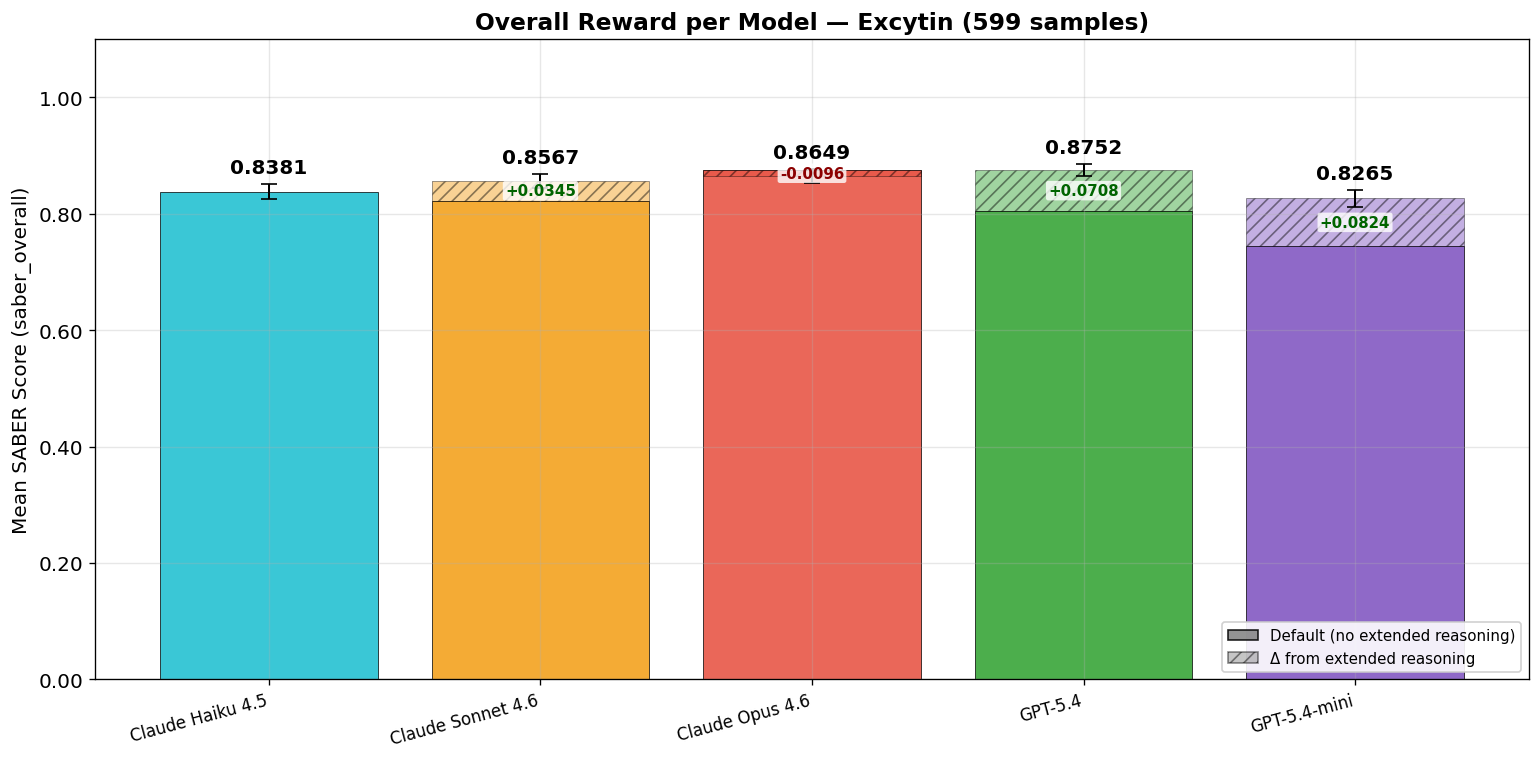

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores bar chart
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))
means = [overall_df.loc[m, 'mean'] for m in MODEL_ORDER]
stderrs = [overall_df.loc[m, 'stderr'] for m in MODEL_ORDER]
colors = [COLORS[m] for m in MODEL_ORDER]

base_heights, delta_heights = [], []
for m in MODEL_ORDER:
    if m in no_thinking_overall:
        base_heights.append(no_thinking_overall[m]['mean'])
        delta_heights.append(overall_df.loc[m, 'mean'] - no_thinking_overall[m]['mean'])
    else:
        base_heights.append(overall_df.loc[m, 'mean'])
        delta_heights.append(0.0)

x = np.arange(len(MODEL_ORDER))
ax.bar(x, base_heights, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, m in enumerate(MODEL_ORDER):
    if delta_heights[i] != 0:
        ax.bar(i, abs(delta_heights[i]),
               bottom=base_heights[i] if delta_heights[i] > 0 else base_heights[i] + delta_heights[i],
               color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for i, m in enumerate(MODEL_ORDER):
    if m in no_thinking_overall:
        d = delta_heights[i]
        mid_y = base_heights[i] + d / 2
        color_text = '#006400' if d > 0 else '#8B0000'
        ax.text(i, mid_y, f'{d:+.4f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color=color_text, bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Model — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
solid_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default (no extended reasoning)')
hatch_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ from extended reasoning')
ax.legend(handles=[solid_patch, hatch_patch], loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Group Breakdown *(Domain-Specific)*

### What this measures

Scores broken down by the **grouping dimension** configured in `GROUP_FN`. This is a **domain-specific experiment** — each SABER domain groups tasks differently, and you must define a `GROUP_FN` that maps sample IDs to group labels for your domain.

| Domain | Group Dimension | `GROUP_FN` |
|--------|-----------------|------------|
| **Excytin** | Security incident (8 incidents, ~72 tasks each) | `'_'.join(id.split('_')[:2])` |
| **CyBench** | Challenge type | `'_'.join(id.split('_')[:-2])` |
| **CTI Realm** | Platform/OS | `id.split('_')[0]` |

### How to read the chart

- Each cluster = one group; bars = models
- Task counts shown below each group name
- Hatched overlays = reasoning delta

> **Note:** If you set `GROUP_FN = None` in the Configuration cell, this section is skipped.

### Key insights (Excytin)

- **Easiest**: incident_134 (avg=0.957) — all models score ≥0.914
- **Hardest**: incident_55 (avg=0.780) — significant model-dependent variation
- Model rankings shift across incidents — no single model dominates all 8 scenarios
- Per-incident breakdown:
  - **incident_55** (n=100): avg=0.780, best=GPT-5.4 (0.826)
  - **incident_5** (n=100): avg=0.786, best=Claude Sonnet 4.6 (0.831)
  - **incident_39** (n=100): avg=0.811, best=Claude Opus 4.6 (0.844)
  - **incident_322** (n=57): avg=0.875, best=Claude Opus 4.6 (0.896)
  - **incident_166** (n=87): avg=0.879, best=GPT-5.4 (0.943)
  - **incident_38** (n=12): avg=0.892, best=Claude Haiku 4.5 (0.917)
  - **incident_34** (n=85): avg=0.944, best=GPT-5.4-mini (0.965)
  - **incident_134** (n=58): avg=0.957, best=GPT-5.4 (0.983)


═══ Per-Incident Mean Scores ═══
model         Claude Haiku 4.5  Claude Sonnet 4.6  Claude Opus 4.6  GPT-5.4  GPT-5.4-mini
group                                                                                    
incident_134            0.9138             0.9569           0.9655   0.9828        0.9655
incident_166            0.8391             0.8563           0.8851   0.9425        0.8736
incident_322            0.8874             0.8626           0.8962   0.8904        0.8406
incident_34             0.9294             0.9353           0.9471   0.9412        0.9647
incident_38             0.9167             0.8333           0.8750   0.9167        0.9167
incident_39             0.8142             0.8042           0.8442   0.8033        0.7900
incident_5              0.7842             0.8308           0.8000   0.8058        0.7083
incident_55             0.7562             0.8100           0.7858   0.8258        0.7233

  incident_134: 58 tasks
  incident_166: 87 tasks
  incident_322: 

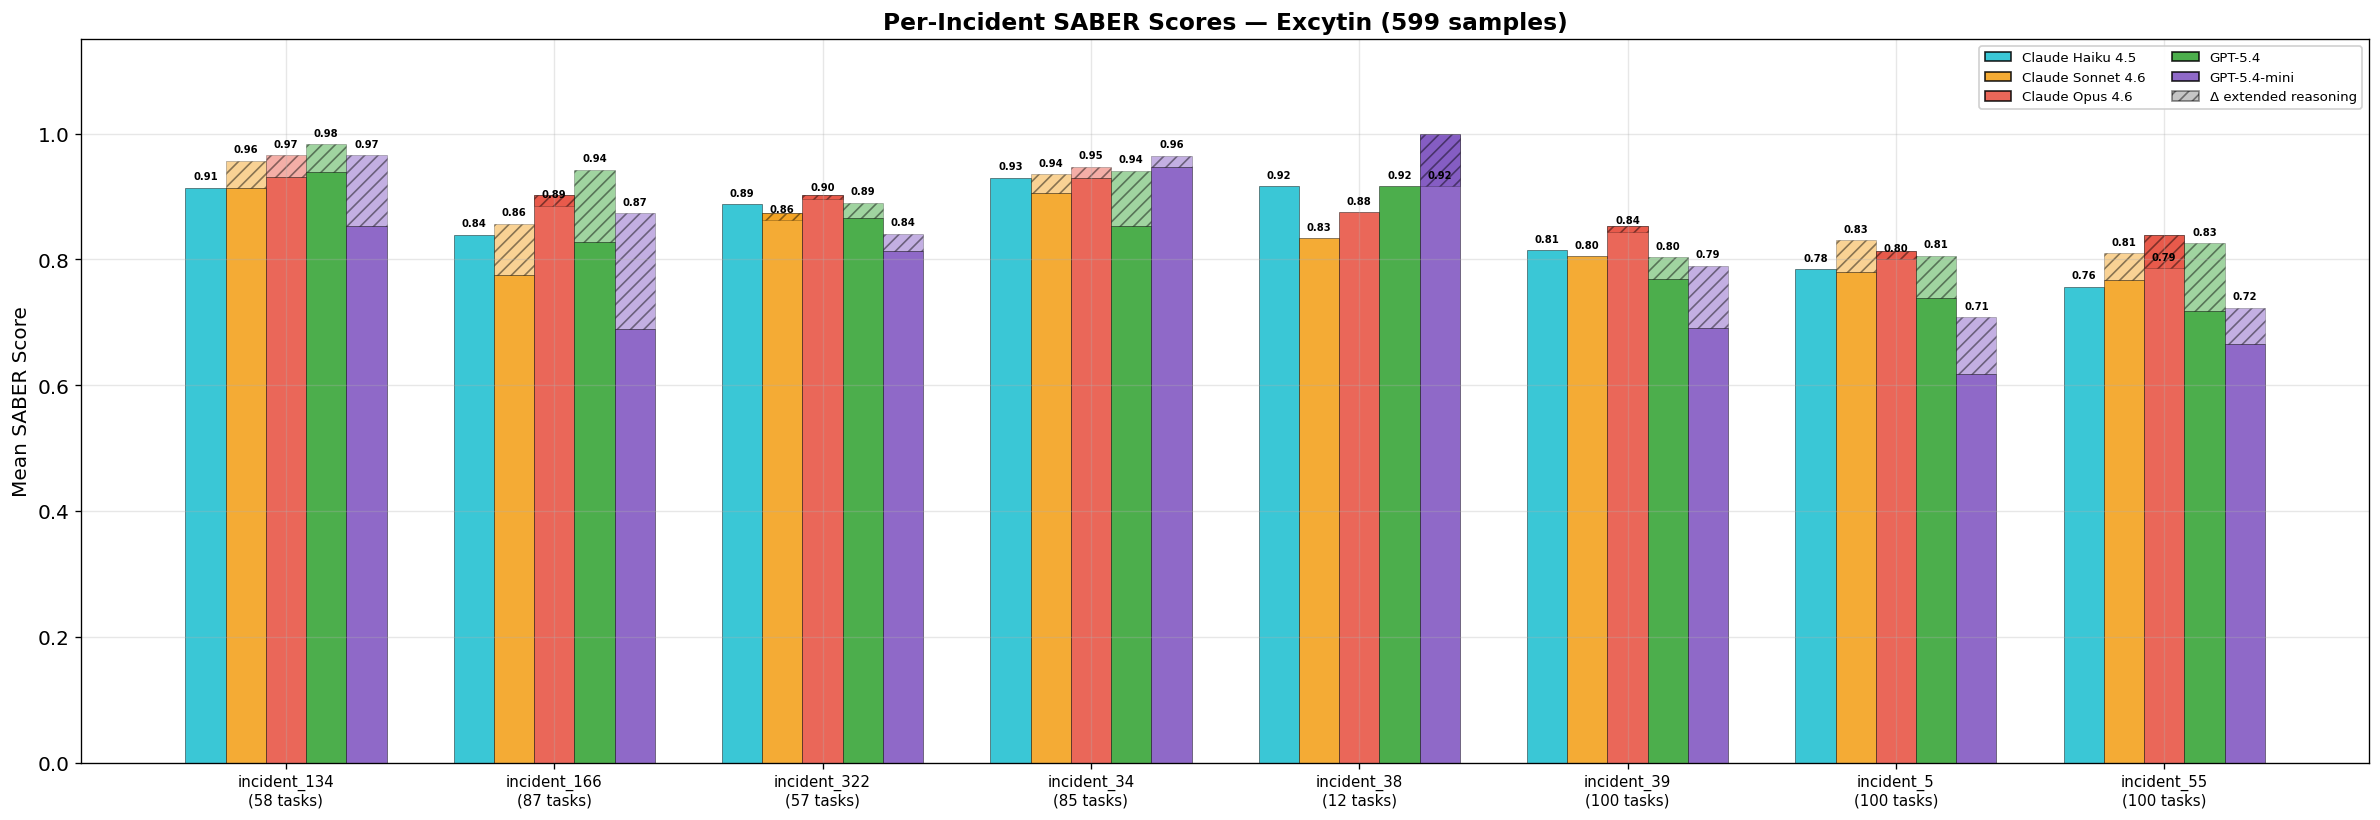

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-group breakdown (configurable grouping dimension)
# ══════════════════════════════════════════════════════════════════════════════
if GROUP_FN is None:
    print('⏭ Per-group analysis skipped (GROUP_FN is None)')
else:
    group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
    group_scores = group_scores.sort_index()
    group_counts = samples_df[samples_df['model'] == MODEL_ORDER[0]].groupby('group').size()

    baseline_group = pd.DataFrame()
    if len(baseline_samples_df) > 0:
        baseline_group = baseline_samples_df.groupby(['group', 'model'])['score'].mean().unstack('model')
        baseline_group = baseline_group.reindex(index=group_scores.index, columns=MODEL_ORDER)

    print(f'═══ Per-{GROUP_LABEL} Mean Scores ═══')
    print(group_scores.round(4).to_string())
    print()
    for grp, cnt in group_counts.items():
        print(f'  {grp}: {cnt} tasks')

    fig, ax = plt.subplots(figsize=(max(14, len(group_scores) * 2.5), 7))
    n_groups = len(group_scores)
    n_models = len(MODEL_ORDER)
    bar_width = min(0.15, 0.8 / n_models)
    xg = np.arange(n_groups)

    for i, model in enumerate(MODEL_ORDER):
        offset = (i - n_models/2 + 0.5) * bar_width
        full_vals = group_scores[model].values
        has_baseline = (model in no_thinking_overall and len(baseline_group) > 0
                        and model in baseline_group.columns)

        if has_baseline:
            base_vals = baseline_group[model].values
            ax.bar(xg + offset, base_vals, bar_width, color=COLORS[model],
                   edgecolor='black', linewidth=0.3, alpha=0.85)
            for xi_idx in range(len(xg)):
                d = full_vals[xi_idx] - base_vals[xi_idx]
                if abs(d) > 0.001:
                    ax.bar(xg[xi_idx] + offset, abs(d),
                           bottom=base_vals[xi_idx] if d > 0 else full_vals[xi_idx],
                           width=bar_width, color=COLORS[model],
                           edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(xg + offset, full_vals, bar_width, color=COLORS[model],
                   edgecolor='black', linewidth=0.3, alpha=0.85)

        for xi, v in zip(xg, full_vals):
            ax.text(xi + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom',
                    fontsize=6, fontweight='bold')

    handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in MODEL_ORDER]
    handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9, ncol=2)

    ax.set_xticks(xg)
    labels = [f'{grp}\n({group_counts.get(grp, "?")} tasks)' for grp in group_scores.index]
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Mean SABER Score')
    ax.set_title(f'Per-{GROUP_LABEL} SABER Scores — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
    ax.set_ylim(0, 1.15)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'per_{GROUP_LABEL.lower()}_scores.png', bbox_inches='tight')
    plt.show()

---

## 3. Cost Analysis

### What this measures

Quantifies **total cost**, **cost per sample**, and **score-cost tradeoffs** for each model using token counts from eval logs and published API pricing.

### Charts

1. **Total Eval Cost** — absolute dollar cost of the full benchmark run
2. **Cost per Sample** — average cost per task (useful for budgeting)
3. **Score vs. Cost (Pareto)** — upper-left = best value; arrows show the cost of enabling reasoning

### Key insights (Excytin)

> **To add pricing for your model:** Update `PRICING` in the Configuration cell.

- **Claude Haiku 4.5** is by far the best value: $35 total ($0.06/sample) for 0.84 score

- **GPT-5.4** is the most expensive at $672 ($1.12/sample) — 19× more than Haiku for only +0.04 score- The Pareto frontier runs Haiku → Sonnet → Opus → GPT-5.4, with steep diminishing returns after Sonnet

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Token usage & cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model').reindex(MODEL_ORDER)
_baseline_rows = extract_cost_rows(NO_THINKING_LOGS, LOG_DIR, PRICING, N_SAMPLES)
baseline_cost_df = pd.DataFrame(_baseline_rows).set_index('model') if _baseline_rows else pd.DataFrame()

print('═══ Cost Breakdown (with extended reasoning) ═══')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
if len(baseline_cost_df) > 0:
    print()
    print('═══ Cost Breakdown (default / no reasoning) ═══')
    print(baseline_cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('═══ Token Usage (with extended reasoning) ═══')
token_cols = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens', 'total_tokens']
print(cost_df[token_cols].to_string())

═══ Cost Breakdown (with extended reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Haiku 4.5    0.84       34.95             0.06
Claude Sonnet 4.6   0.86      120.48             0.20
Claude Opus 4.6     0.86      441.78             0.74
GPT-5.4             0.88      671.79             1.12
GPT-5.4-mini        0.83      117.78             0.20

═══ Cost Breakdown (default / no reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Sonnet 4.6   0.82       79.70             0.13
Claude Opus 4.6     0.87      429.37             0.72
GPT-5.4             0.80      254.77             0.43
GPT-5.4-mini        0.74       54.75             0.09

═══ Token Usage (with extended reasoning) ═══
                   input_tokens  output_tokens  cache_read  cache_write  reasoning_tokens  total_tokens
model                                            

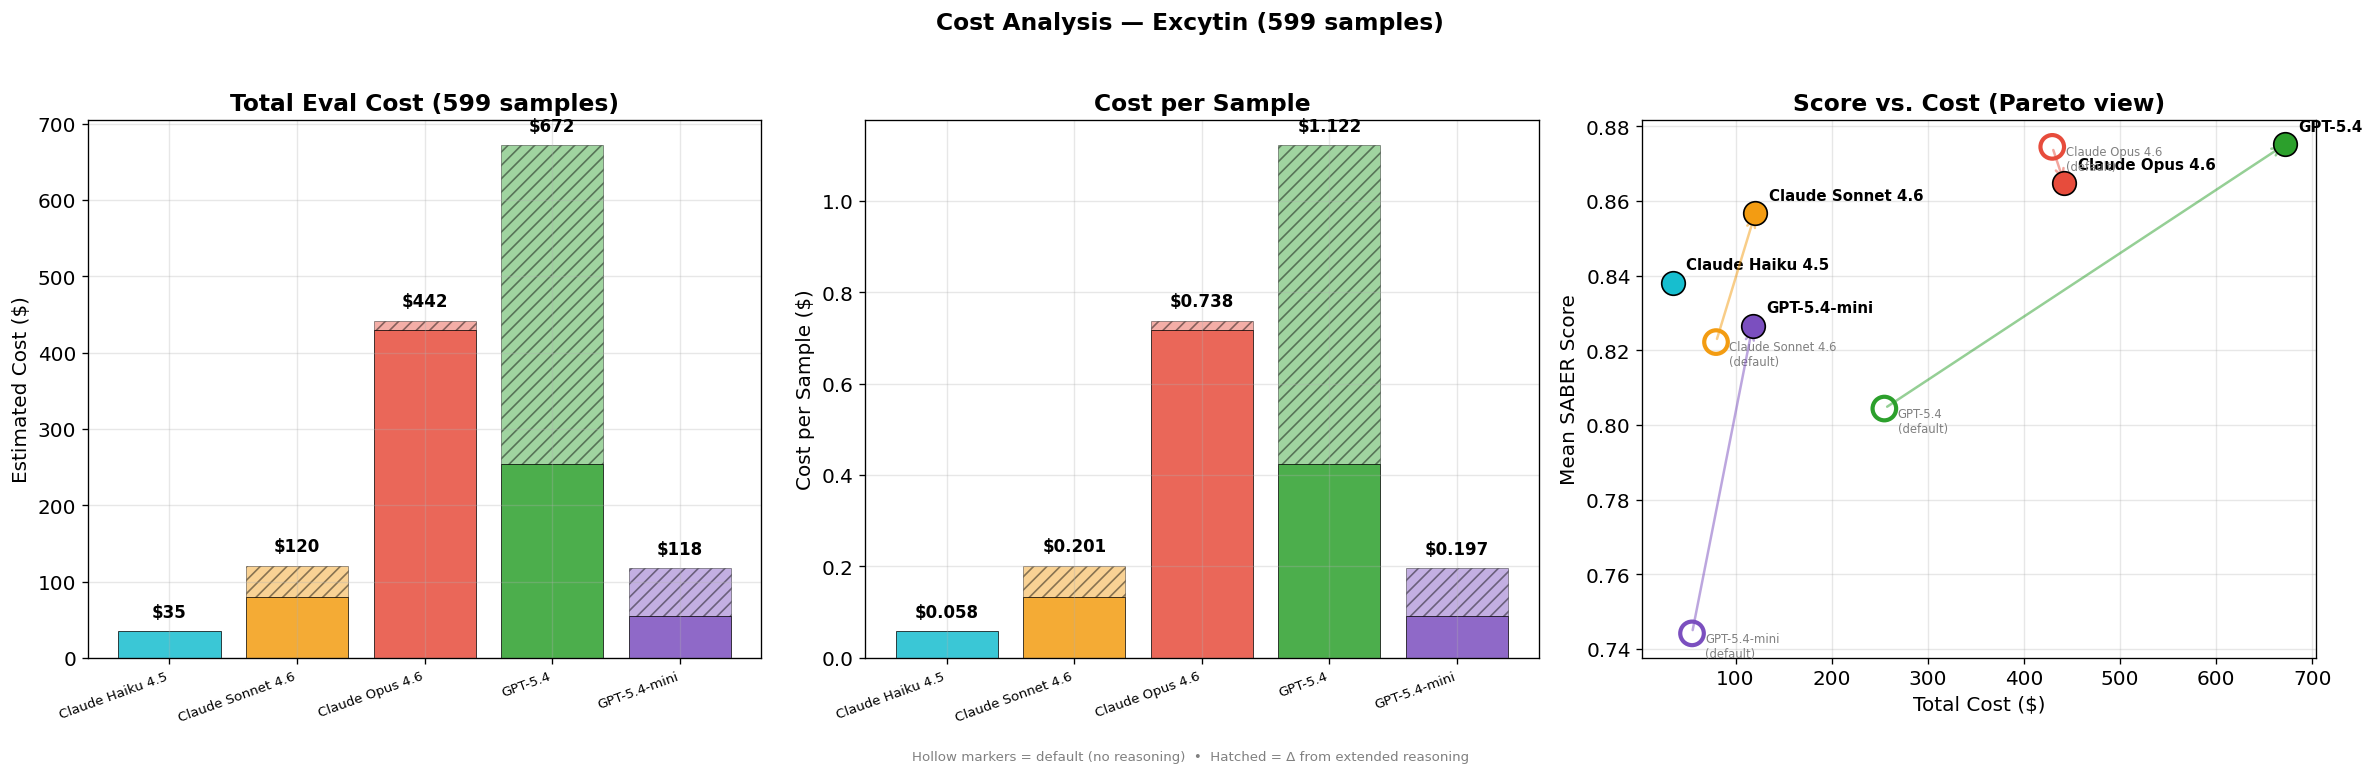

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization — total, per-sample, Pareto
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

# Panel 1: Total cost
ax = axes[0]
for i, m in enumerate(MODEL_ORDER):
    tc = cost_df.loc[m, 'total_cost']
    if m in baseline_cost_df.index:
        base_tc = baseline_cost_df.loc[m, 'total_cost']
        ax.bar(i, base_tc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_tc = tc - base_tc
        ax.bar(i, abs(delta_tc), bottom=base_tc if delta_tc > 0 else tc,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, tc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, tc + cost_df['total_cost'].max()*0.02, f'${tc:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Estimated Cost ($)'); ax.set_title(f'Total Eval Cost ({N_SAMPLES} samples)', fontweight='bold')

# Panel 2: Cost per sample
ax = axes[1]
for i, m in enumerate(MODEL_ORDER):
    cps_val = cost_df.loc[m, 'cost_per_sample']
    if m in baseline_cost_df.index:
        base_cps = baseline_cost_df.loc[m, 'cost_per_sample']
        ax.bar(i, base_cps, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_cps = cps_val - base_cps
        ax.bar(i, abs(delta_cps), bottom=base_cps if delta_cps > 0 else cps_val,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, cps_val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, cps_val + cost_df['cost_per_sample'].max()*0.02, f'${cps_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Cost per Sample ($)'); ax.set_title('Cost per Sample', fontweight='bold')

# Panel 3: Pareto
ax = axes[2]
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
for m in baseline_cost_df.index:
    if m not in COLORS: continue
    brow = baseline_cost_df.loc[m]
    ax.scatter(brow['total_cost'], brow['score'], s=200, facecolors='none', edgecolors=COLORS[m], linewidth=2.5, zorder=4)
    ax.annotate(f'{m}\n(default)', (brow['total_cost'], brow['score']), textcoords='offset points', xytext=(8, -14), fontsize=7, fontstyle='italic', color='gray')
    ax.annotate('', xy=(cost_df.loc[m, 'total_cost'], cost_df.loc[m, 'score']), xytext=(brow['total_cost'], brow['score']),
                arrowprops=dict(arrowstyle='->', color=COLORS[m], lw=1.5, alpha=0.5))
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto view)', fontweight='bold')

fig.suptitle(f'Cost Analysis — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold', fontsize=14, y=1.02)
fig.text(0.5, -0.02, 'Hollow markers = default (no reasoning)  •  Hatched = Δ from extended reasoning',
         ha='center', fontsize=8, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Token Usage Breakdown

### What this measures

Decomposes **where tokens are spent** per model: input, output, cache reads/writes, and reasoning tokens.

- **Input** — prompts, tool results, conversation history
- **Output** — model-generated text, tool calls, answers
- **Cache Read/Write** — prompt caching (reduces cost)
- **Reasoning** — internal chain-of-thought (extended thinking)
- **Solid** = default mode; **Hatched** = additional from extended reasoning

### Key insights (Excytin)

- **Claude Opus 4.6** and **GPT-5.4** consume the most tokens overall, driven primarily by output tokens and reasoning
- **Claude Haiku 4.5** is the most token-efficient model — consistent with its low cost
- Cache read tokens are significant for Claude models (prompt caching reduces repeated prefix costs)
- Reasoning tokens (extended thinking) add substantial overhead for GPT-5.4 and Claude Sonnet but minimal for Haiku


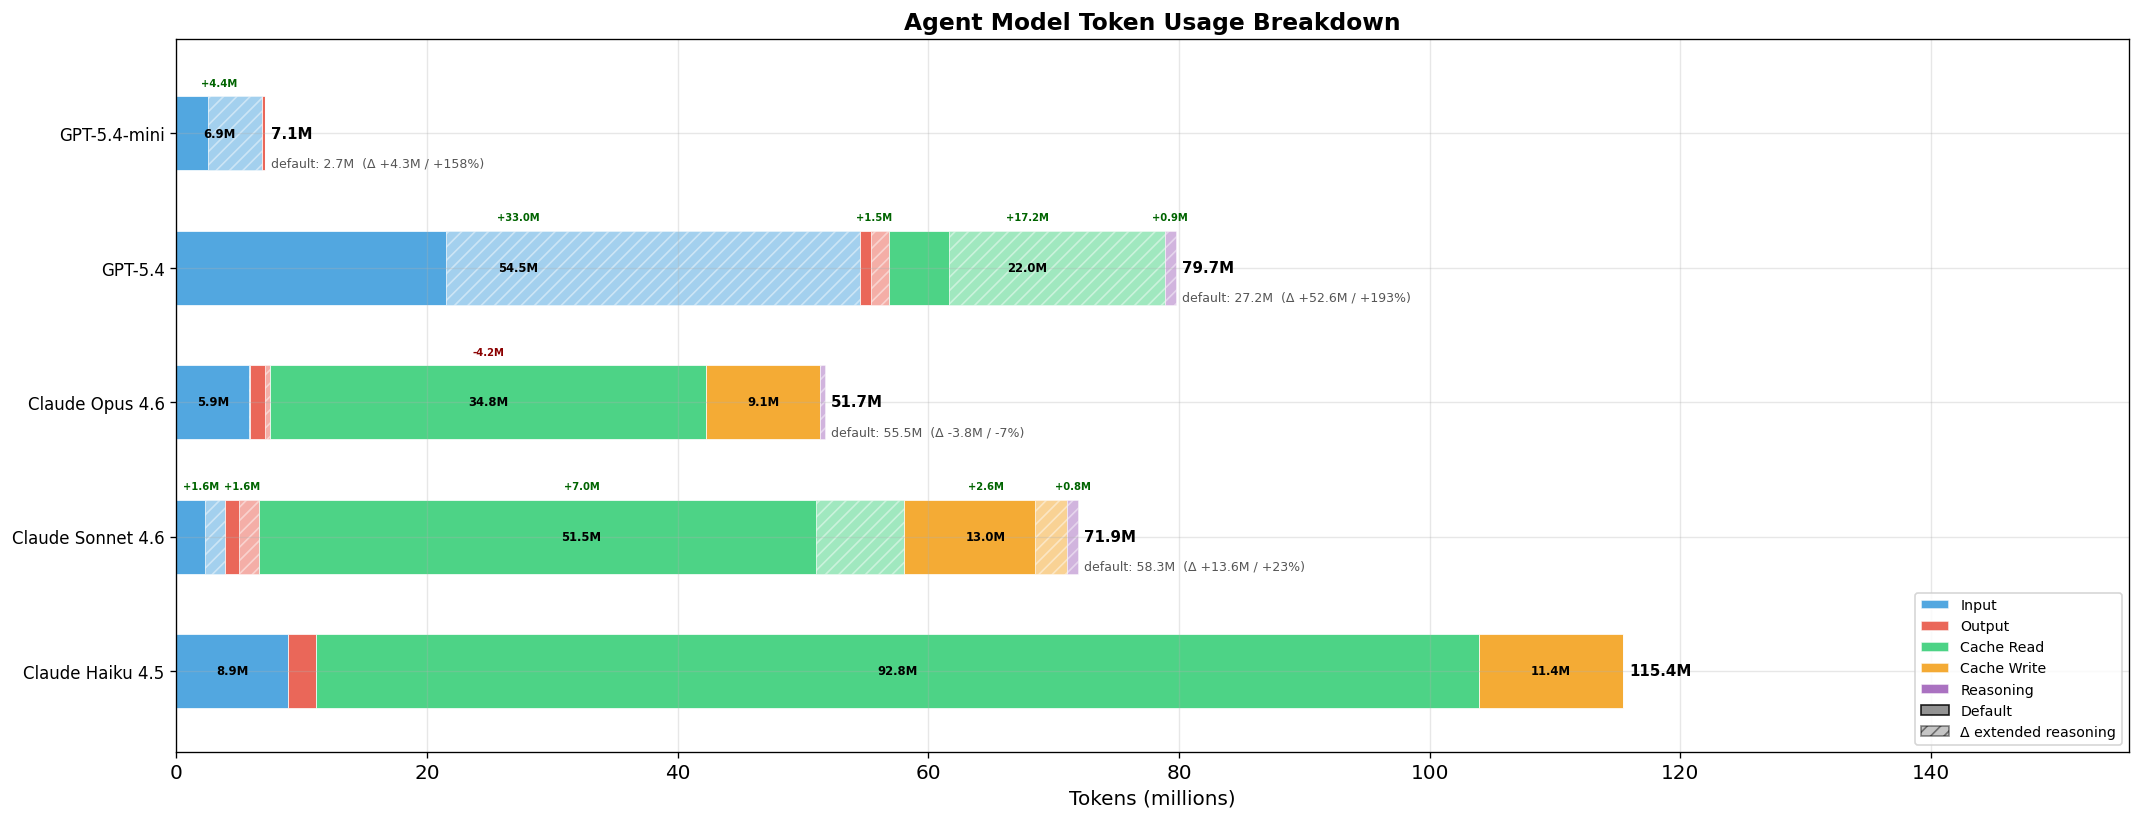

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, max(5, len(MODEL_ORDER) * 1.4)))
bar_height = 0.55
all_totals = [sum(cost_df.loc[m][k]/1e6 for k in token_keys) for m in MODEL_ORDER]
global_max = max(all_totals)
MIN_LABEL_WIDTH = global_max * 0.05

for i, m in enumerate(MODEL_ORDER):
    row = cost_df.loc[m]
    vals = [row[k]/1e6 for k in token_keys]
    has_baseline = m in baseline_cost_df.index
    bvals = [baseline_cost_df.loc[m][k]/1e6 for k in token_keys] if has_baseline else vals

    left = 0
    for j, (rv, bv, c) in enumerate(zip(vals, bvals, cat_colors)):
        if has_baseline and rv > 0:
            solid_w = min(rv, bv)
            delta_w = rv - bv
            ax.barh(i, solid_w, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
            if delta_w > 0.01:
                ax.barh(i, delta_w, left=left + solid_w, height=bar_height, color=c,
                        edgecolor='white', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.barh(i, rv, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if rv >= MIN_LABEL_WIDTH:
            ax.text(left + rv/2, i, f'{rv:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        if has_baseline and abs(rv - bv) > 0.4:
            ax.text(left + rv/2, i + bar_height/2 + 0.06, f'{rv - bv:+.1f}M', ha='center', va='bottom',
                    fontsize=6, fontweight='bold', color='#006400' if rv > bv else '#8B0000')
        left += rv

    total_m = sum(vals)
    ax.text(left + 0.5, i, f'{total_m:.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')
    if has_baseline:
        base_total = sum(bvals)
        ax.text(left + 0.5, i - 0.22,
                f'default: {base_total:.1f}M  (Δ {total_m - base_total:+.1f}M / {(total_m - base_total)/base_total*100:+.0f}%)',
                va='center', ha='left', fontsize=7.5, fontstyle='italic', color='#555')

ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Tokens (millions)'); ax.set_title('Agent Model Token Usage Breakdown', fontweight='bold')
ax.set_xlim(right=global_max * 1.35); ax.set_ylim(-0.6, len(MODEL_ORDER) - 0.3)

legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
legend_handles += [mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage_breakdown.png', bbox_inches='tight')
plt.show()

---

## 5. Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Mean SABER Score}}{\text{Total Cost (\$)}}$$

Higher = better value. The most cost-efficient model is not always the highest-scoring one.

- For budget-constrained deployments, Haiku is the clear winner; for maximum capability, GPT-5.4 leads but at extreme cost

### Key insights (Excytin)- **Claude Haiku 4.5** delivers 0.024 score per dollar — **12× more efficient** than GPT-5.4 (0.002) and **3.4× more** than Sonnet/GPT-5.4-mini (~0.007)


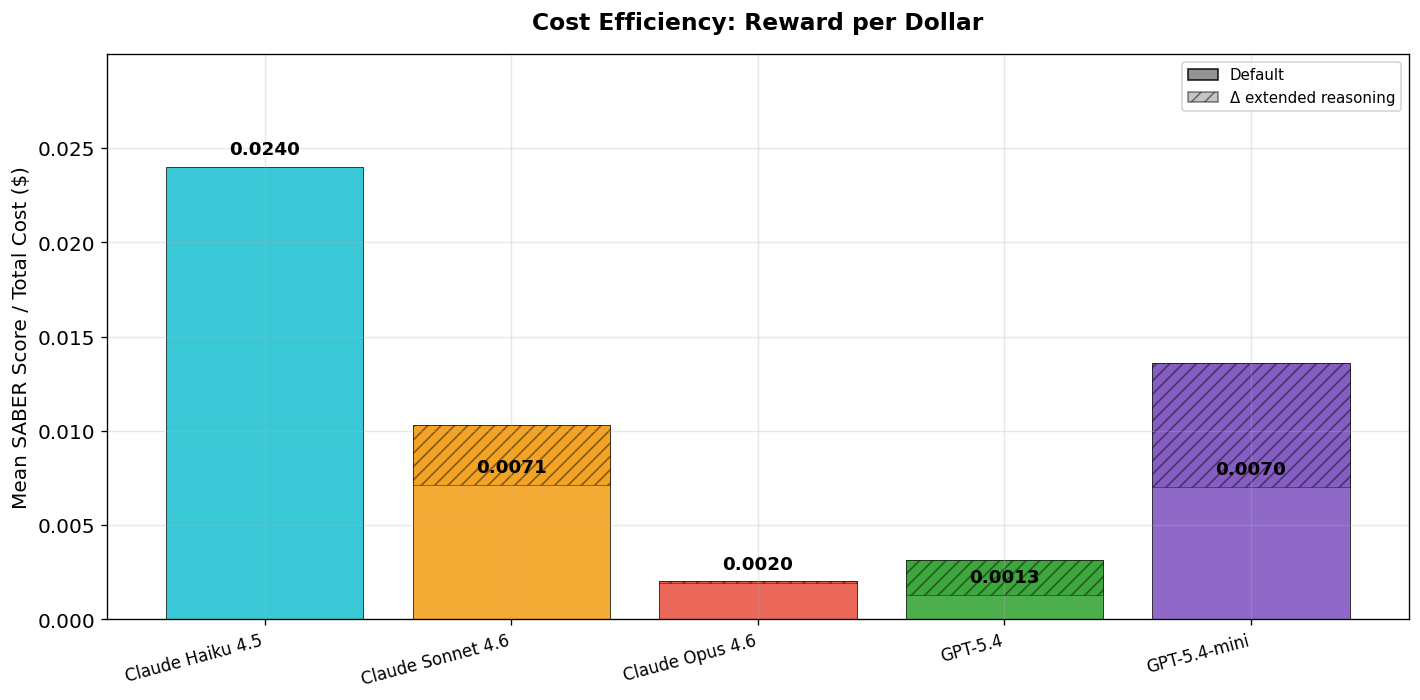

═══ Cost Efficiency Summary ═══
Model                      Score     Cost   $/sample    Score/$
────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838 $  34.95 $   0.0584    0.02398
Claude Sonnet 4.6          0.857 $ 120.48 $   0.2011    0.00711
Claude Opus 4.6            0.865 $ 441.78 $   0.7375    0.00196
GPT-5.4                    0.875 $ 671.79 $   1.1215    0.00130
GPT-5.4-mini               0.827 $ 117.78 $   0.1966    0.00702


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency — reward per dollar
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

reward_per_dollar = cost_df['score'] / cost_df['total_cost']
baseline_rpd = baseline_cost_df['score'] / baseline_cost_df['total_cost'] if len(baseline_cost_df) > 0 else pd.Series(dtype=float)

for i, m in enumerate(MODEL_ORDER):
    rpd_val = reward_per_dollar[m]
    if m in baseline_rpd.index:
        base_rpd = baseline_rpd[m]
        ax.bar(i, base_rpd, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_rpd = rpd_val - base_rpd
        ax.bar(i, abs(delta_rpd), bottom=base_rpd if delta_rpd > 0 else rpd_val,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, rpd_val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpd_val + reward_per_dollar.max()*0.02, f'{rpd_val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score / Total Cost ($)')
ax.set_title('Cost Efficiency: Reward per Dollar', fontweight='bold', pad=15)
ax.set_ylim(0, reward_per_dollar.max() * 1.25)
solid_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default')
hatch_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')
ax.legend(handles=[solid_patch, hatch_patch], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('─' * 60)
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    rpd = row['score'] / row['total_cost']
    print(f'{m:25s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd:10.5f}')

---

## 6. Sub-Task Score Breakdown

### What this measures

Each task produces three score types:
- **Submission** — final answer correctness (LLM-judge or static match)
- **Checkpoints** — intermediate investigative steps (varies: 2 for Excytin, 5 for CTI Realm, 6 for CyBench)
- **Aggregate** — weighted combination feeding into `saber_overall`

A model with high submission but low checkpoints may be guessing — risky for production.

- Checkpoint scores are universally low (0.20–0.27), suggesting the intermediate investigation steps remain challenging for all models

### Key insights (Excytin)- **GPT-5.4** has the highest checkpoint score (0.271 — 33% higher than Opus) — it follows the investigative process more thoroughly

- **Claude Opus 4.6** has the highest submission score (0.756) but the *lowest* checkpoint score (0.203) — it may be taking shortcuts

═══ Sub-Task Mean Scores (with extended reasoning) ═══
category           Submission  Checkpoints  Aggregate
model                                                
Claude Haiku 4.5       0.6795       0.2374     0.8381
Claude Sonnet 4.6      0.7045       0.2185     0.8567
Claude Opus 4.6        0.7563       0.2028     0.8649
GPT-5.4                0.6828       0.2709     0.8752
GPT-5.4-mini           0.7179       0.2489     0.8265


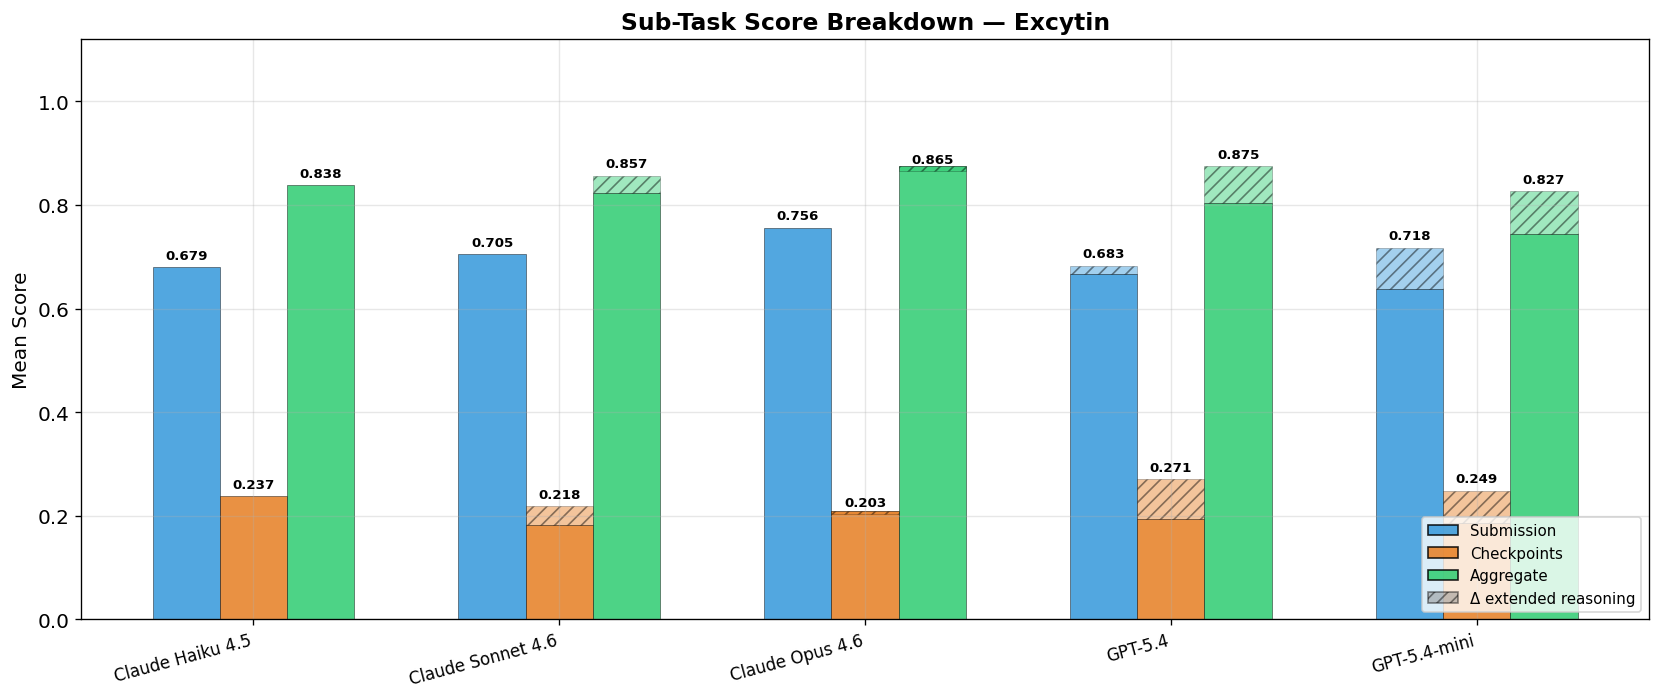

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown — Submission vs Checkpoints vs Aggregate
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)
cat_means = subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
available_cats = [c for c in ['Submission', 'Checkpoints', 'Aggregate'] if c in cat_means.columns]
cat_means = cat_means.reindex(MODEL_ORDER)[available_cats]

baseline_cat_means = pd.DataFrame()
if len(baseline_subtasks_df) > 0:
    baseline_subtasks_df['category'] = baseline_subtasks_df['score_type'].apply(classify_score_type)
    baseline_cat_means = baseline_subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
    baseline_cat_means = baseline_cat_means.reindex(columns=available_cats)

print('═══ Sub-Task Mean Scores (with extended reasoning) ═══')
print(cat_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71'][:len(available_cats)]
x = np.arange(len(MODEL_ORDER))
bar_width = 0.22

for j, (cat, color) in enumerate(zip(available_cats, cat_plot_colors)):
    offset = (j - len(available_cats)/2 + 0.5) * bar_width
    for i, m in enumerate(MODEL_ORDER):
        full_val = cat_means.loc[m, cat]
        has_base = (len(baseline_cat_means) > 0 and m in baseline_cat_means.index
                    and not pd.isna(baseline_cat_means.loc[m, cat]) if cat in baseline_cat_means.columns else False)
        if has_base:
            base_val = baseline_cat_means.loc[m, cat]
            ax.bar(x[i] + offset, base_val, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
            d = full_val - base_val
            if abs(d) > 0.001:
                ax.bar(x[i] + offset, abs(d), bottom=base_val if d > 0 else full_val,
                       width=bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(x[i] + offset, full_val, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
        ax.text(x[i] + offset, full_val + 0.01, f'{full_val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

cat_handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat) for cat, c in zip(available_cats, cat_plot_colors)]
cat_handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=cat_handles, fontsize=9, loc='lower right')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean Score')
ax.set_title(f'Sub-Task Score Breakdown — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'subtask_breakdown.png', bbox_inches='tight')
plt.show()

---

## 7. Checkpoint Score Distributions

Violin plots showing the **full distribution** of checkpoint scores per model. Wide regions = many samples clustered at that score level.

- Bimodal distributions (two peaks) = model either nails it or fails completely
- Tight distributions = consistent performance

- This binary pattern suggests checkpoints are pass/fail in nature — models either complete an investigative step fully or miss it entirely

### Key insights (Excytin)- **GPT-5.4** has the widest spread (highest median ~0.27), while **Claude Opus** is most concentrated near 0

- All models show strongly **bimodal** distributions — checkpoint scores cluster at 0.0 and 1.0 with relatively few partial scores

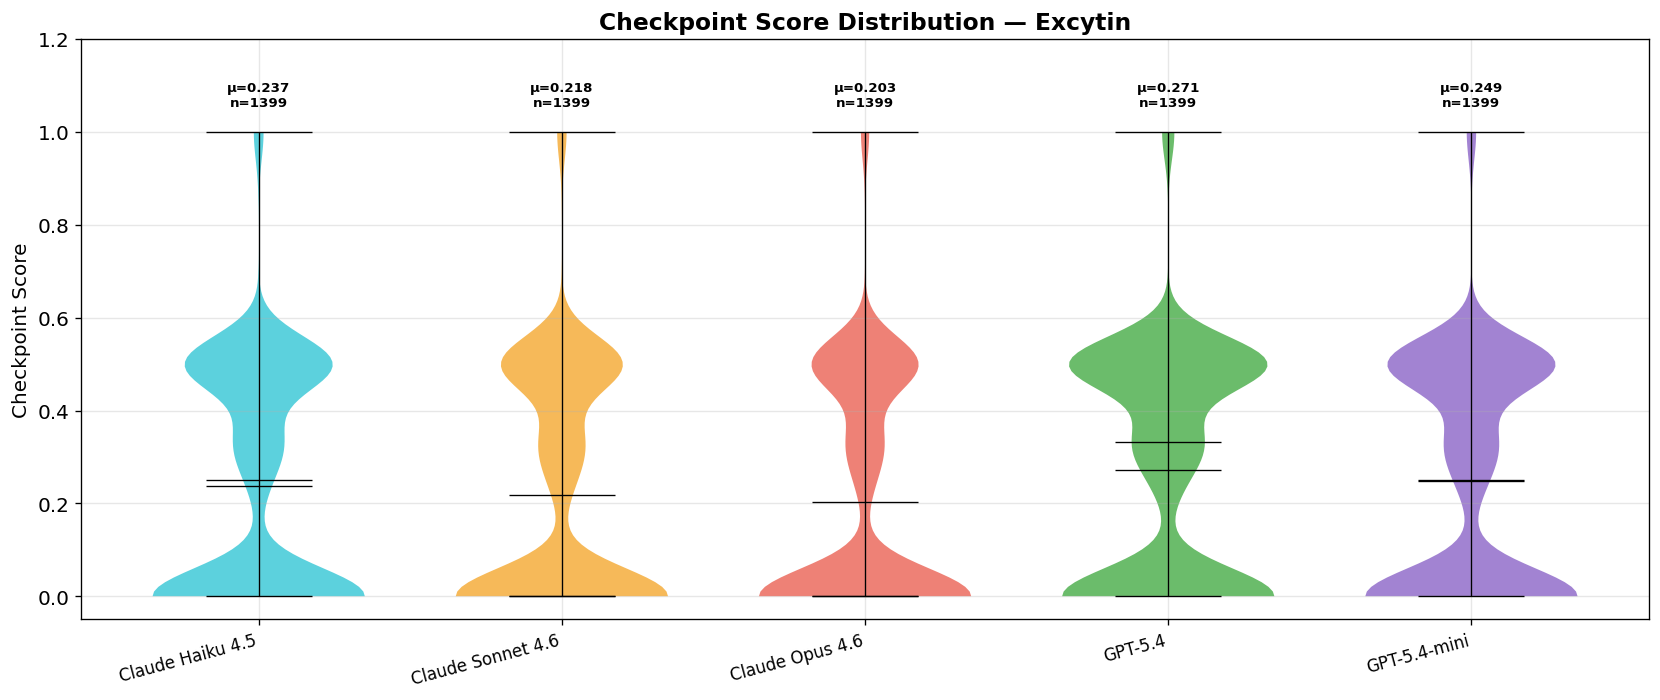

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint score distributions (violin plot)
# ══════════════════════════════════════════════════════════════════════════════
checkpoint_df = subtasks_df[subtasks_df['score_type'].str.startswith('checkpoint')].copy()

fig, ax = plt.subplots(figsize=(14, 6))
positions, tick_labels = [], []

for i, model in enumerate(MODEL_ORDER):
    data = checkpoint_df[checkpoint_df['model'] == model]['score'].values
    if len(data) == 0:
        continue
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[model])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, 1.05, f'μ={np.mean(data):.3f}\nn={len(data)}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    positions.append(i)
    tick_labels.append(model)

ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Checkpoint Score')
ax.set_title(f'Checkpoint Score Distribution — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions.png', bbox_inches='tight')
plt.show()

---

## 8. Agent Trajectory Analysis

### What this measures

Analyses 8–12 examine the **behavioral patterns** of the agent — how many steps it takes, which tools it uses, how efficiently it spends time, and whether more effort correlates with better scores.

This cell loads per-sample trajectory data: steps (assistant turns), tool calls, and timing from each eval log using inspect_ai's typed log API.

- **total_time** — wall-clock seconds per sample

### Key metrics loaded- **tool_counts** — per-tool breakdown (e.g., bash vs. python)

- **n_tool_calls** — actual tool invocations (capped at TOOL_CALL_LIMIT=25 in practice)
- **n_steps** — assistant message turns (can exceed tool call limit since some turns don't use tools)

### Key insights (Excytin)

- **2,995 trajectory samples** loaded (599 per model × 5 models)
- Claude Haiku 4.5 uses the most tool calls on average (~15), while Claude Opus is the most focused (~9)
- All models reach ~95% of their final score by tool-call limit 20–25, suggesting the current cap is adequate
- Only two tools: bash and python — consistent with Excytin's SQL-based investigation workflows


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAJECTORY DATA LOADING — Per-sample steps, tool calls, and timing
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

traj_df = load_trajectory_data(EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN)

# Normalize tool names to lowercase (e.g. "Bash" and "bash" → "bash")
traj_df['tool_counts'] = traj_df['tool_counts'].apply(
    lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
)

# Flatten tool_counts dicts into separate columns per tool
all_tools = sorted({t for tc in traj_df['tool_counts'] for t in tc})
for tool in all_tools:
    traj_df[f'tool_{tool}'] = traj_df['tool_counts'].apply(lambda d, t=tool: d.get(t, 0))

print(f'✓ Loaded trajectory data: {len(traj_df)} samples × {traj_df["model"].nunique()} models')
print(f'  Tools observed: {all_tools}')
print()
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    print(f'  {m:25s}  steps={mdf.n_steps.mean():.1f}±{mdf.n_steps.std():.1f}  '
          f'tool_calls={mdf.n_tool_calls.mean():.1f}±{mdf.n_tool_calls.std():.1f}  '
          f'time={mdf.total_time.mean():.0f}s±{mdf.total_time.std():.0f}s')

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/amudgerikar/conda/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7a9bec2f7bc0> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-5937' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/amudgerikar/repos/oss_saber/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-5939' coro=<Kernel.shell_main() running at /home/amudgerikar/repos/oss_saber/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/amudgerikar/repos/oss_saber/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/amudgerikar/conda

✓ Loaded trajectory data: 2995 samples × 5 models
  Tools observed: ['bash', 'python']

  Claude Haiku 4.5           steps=16.2±7.1  tool_calls=15.3±7.1  time=115s±48s
  Claude Sonnet 4.6          steps=8.1±4.6  tool_calls=11.1±7.6  time=108s±92s
  Claude Opus 4.6            steps=7.7±5.1  tool_calls=9.4±6.1  time=86s±152s
  GPT-5.4                    steps=10.2±4.9  tool_calls=10.9±5.6  time=743s±950s
  GPT-5.4-mini               steps=10.3±5.8  tool_calls=10.2±6.2  time=149s±98s


### 8a. Mean Score vs. Tool-Call Limit — What's the Optimal Budget?

For each tool-call limit N on the x-axis, compute the mean score across **all samples**, where samples that needed > N tool calls get score 0 (wouldn't have finished under that budget). This shows where returns from allowing more tool calls diminish.

- **Steeper early rise** = model solves many tasks quickly (efficient)
- **Plateau** = increasing the budget further yields diminishing returns
- Curves converge to each model's actual mean score at limit=25 (the real tool-call cap)

- The checkpoint panel (right) shows partial progress continues to accumulate even at high call counts

### Key insights (Excytin)- All models reach ~95% of their final score by tool-call limit 20–25, suggesting the current cap of 25 is adequate

- **Claude Haiku 4.5** rises most slowly — many of its tasks require 15+ tool calls, making it the most sensitive to a tight budget
- **Claude Opus 4.6** ramps up fastest — reaches 0.70+ by tool-call limit 10, meaning most of its score comes from tasks solved in ≤10 calls

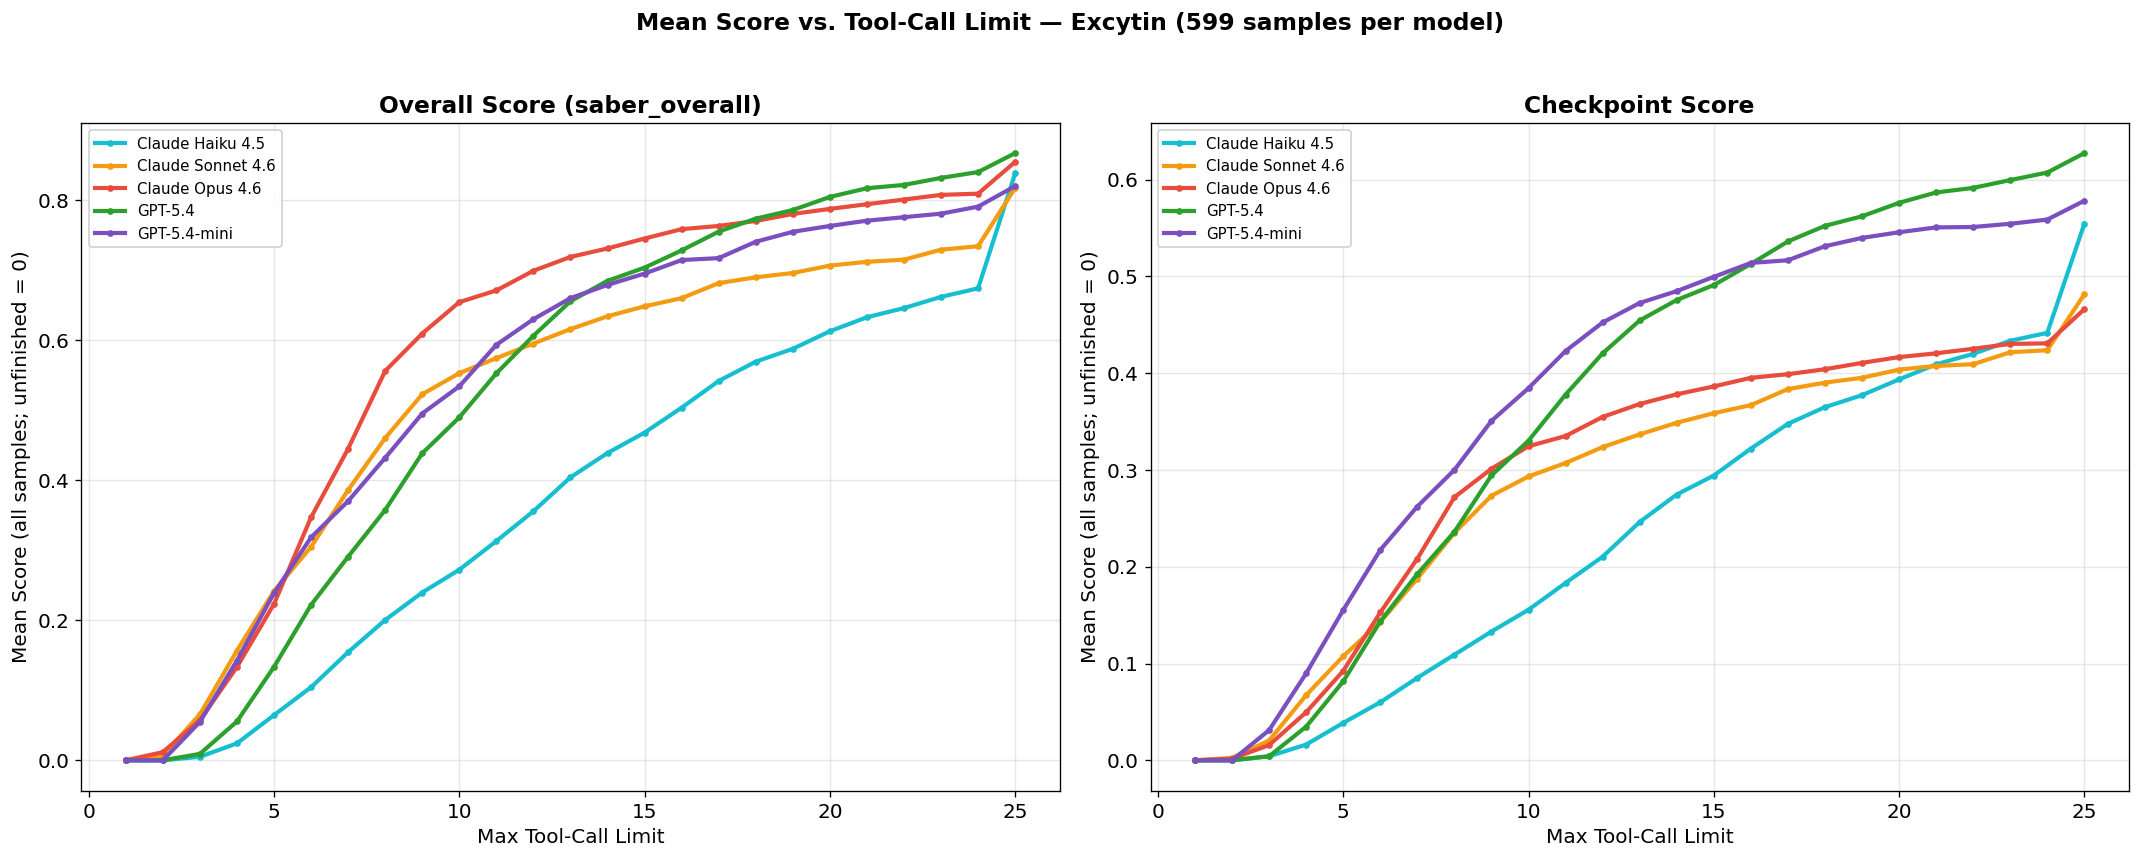

═══ Tool-Call Limit Analysis (overall score) ═══
Tool-call limit at which model reaches 95% of its full score:

  Claude Haiku 4.5           95% at 25 calls  (100% of samples done, full=0.8381)
  Claude Sonnet 4.6          95% at 25 calls  (95% of samples done, full=0.8567)
  Claude Opus 4.6            95% at 25 calls  (99% of samples done, full=0.8649)
  GPT-5.4                    95% at 23 calls  (95% of samples done, full=0.8752)
  GPT-5.4-mini               95% at 24 calls  (94% of samples done, full=0.8265)


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8a: Mean Score vs. Max Tool-Call Limit
#   For each tool-call limit N: samples that finished in ≤ N tool calls keep
#   their actual score; samples that needed > N get score 0.
#   Mean is over ALL N_SAMPLES samples.  Shows where returns from more calls diminish.
# ══════════════════════════════════════════════════════════════════════════════

step_lookup = traj_df[['model', 'sample_id', 'n_tool_calls']].copy()
merged = subtasks_df.merge(step_lookup, on=['model', 'sample_id'], how='inner')
if 'category' not in merged.columns:
    merged['category'] = merged['score_type'].apply(classify_score_type)

call_limits = list(range(1, TOOL_CALL_LIMIT + 1))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, (score_label, score_src) in zip(axes, [
    ('Overall Score (saber_overall)', 'overall'),
    ('Checkpoint Score', 'checkpoint'),
]):
    for m in MODEL_ORDER:
        if score_src == 'overall':
            mdf = traj_df[traj_df['model'] == m].copy()
            total_samples = len(mdf)
        else:
            mdf = merged[(merged['model'] == m) & (merged['category'] == 'Checkpoints')].copy()
            if mdf.empty:
                continue
            total_samples = mdf['sample_id'].nunique()

        means = []
        for limit in call_limits:
            completed = mdf[mdf['n_tool_calls'] <= limit]
            avg = completed['score'].sum() / total_samples if total_samples > 0 else 0
            means.append(avg)

        ax.plot(call_limits, means, color=COLORS[m],
                linewidth=2.5, marker='o', markersize=3, label=m, zorder=5)

    ax.set_xlabel('Max Tool-Call Limit')
    ax.set_ylabel('Mean Score (all samples; unfinished = 0)')
    ax.set_title(score_label, fontweight='bold')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Mean Score vs. Tool-Call Limit — {DOMAIN_NAME} ({N_SAMPLES} samples per model)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'score_vs_tool_call_limit.png', bbox_inches='tight')
plt.show()

# Summary: at what tool-call limit does each model reach 95% of its final score?
print('═══ Tool-Call Limit Analysis (overall score) ═══')
print('Tool-call limit at which model reaches 95% of its full score:\n')
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    total = len(mdf)
    full_score = mdf['score'].mean()
    target = full_score * 0.95
    limit_95 = TOOL_CALL_LIMIT
    for limit in call_limits:
        avg = mdf[mdf['n_tool_calls'] <= limit]['score'].sum() / total
        if avg >= target:
            limit_95 = limit
            break
    pct_done = len(mdf[mdf['n_tool_calls'] <= limit_95]) / total
    print(f'  {m:25s}  95% at {limit_95:2d} calls  '
          f'({pct_done:.0%} of samples done, full={full_score:.4f})')

### 8b. Effort Distribution per Model

How many tool calls and steps does each model use per task? Violin plots show the full distribution.

- **Narrow, low** = efficient (solves tasks quickly)
- **Wide, high** = variable or struggling (many tasks need lots of calls)
- **Long upper tail** = some tasks cause the agent to max out its tool-call budget

### Key insights (Excytin)

- **Claude Opus 4.6** is the most efficient: fewest tool calls (μ≈9.4) and steps (μ≈7.7) while scoring second-highest
- **Claude Haiku 4.5** uses the most tool calls (μ≈15.3) and steps (μ≈16.2) — nearly 2× the effort of Opus/Sonnet, yet scores lowest
- GPT-5.4 and GPT-5.4-mini are similar in effort (~10–11 calls) despite very different scores

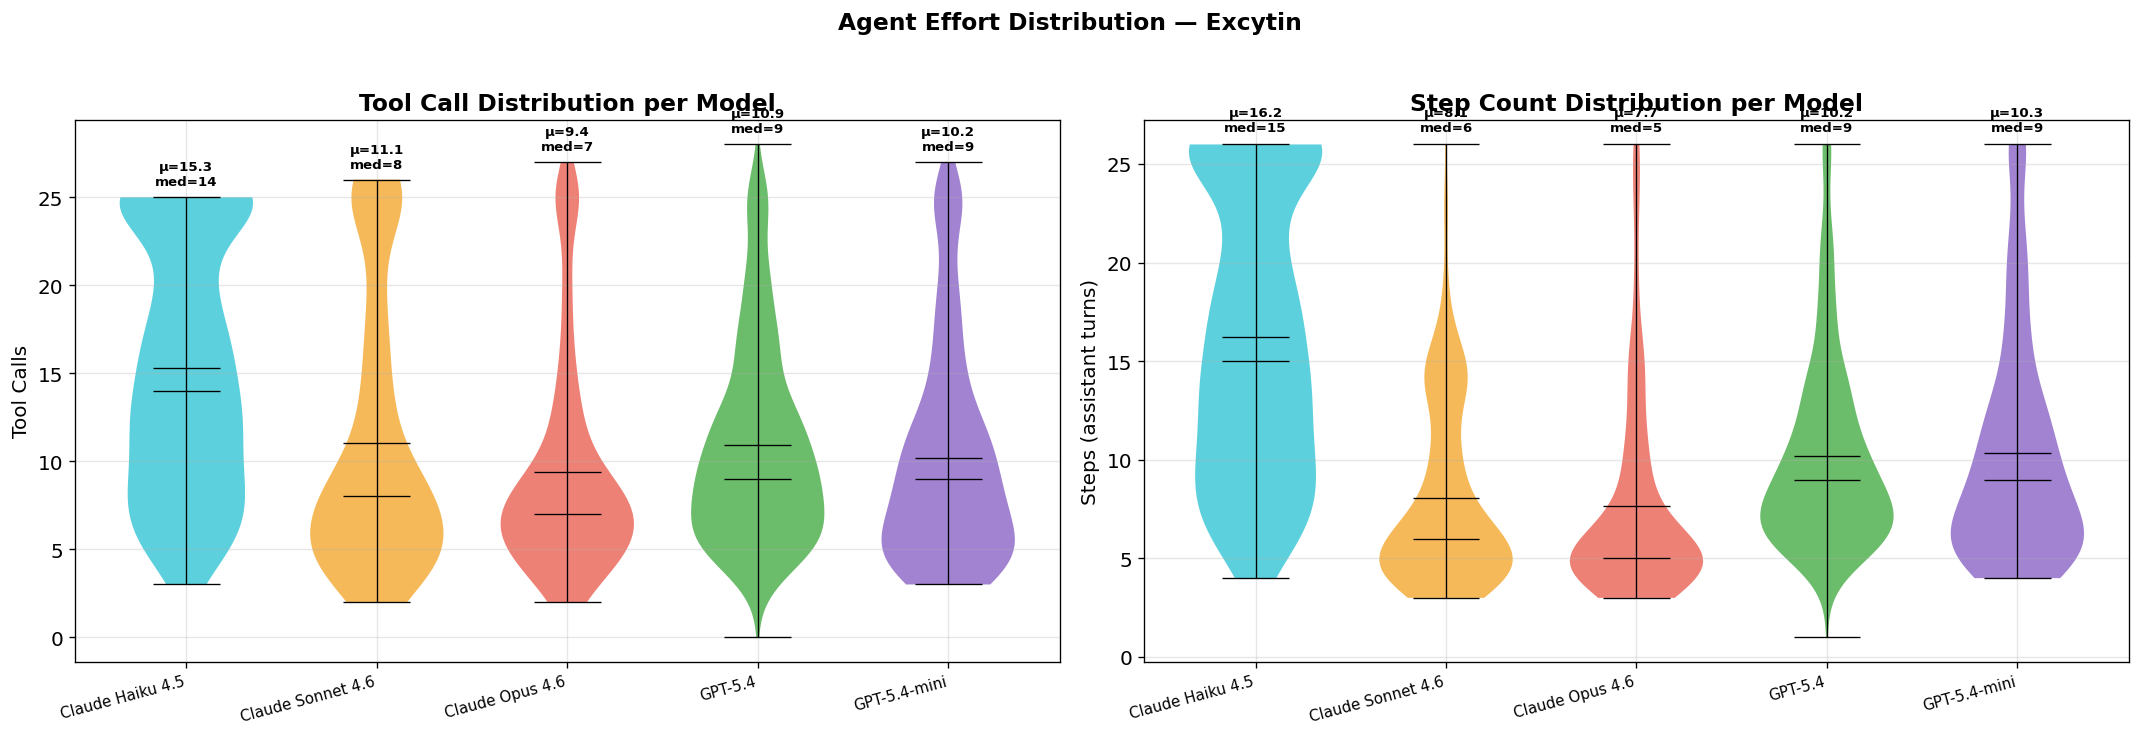

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8b: Tool call & step count distribution (violin + box)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1 (primary): Tool call distribution
ax = axes[0]
for i, m in enumerate(MODEL_ORDER):
    data = traj_df[traj_df['model'] == m]['n_tool_calls'].values
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.5, f'μ={np.mean(data):.1f}\nmed={np.median(data):.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Tool Calls')
ax.set_title('Tool Call Distribution per Model', fontweight='bold')

# Panel 2 (secondary): Step count distribution
ax = axes[1]
for i, m in enumerate(MODEL_ORDER):
    data = traj_df[traj_df['model'] == m]['n_steps'].values
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.5, f'μ={np.mean(data):.1f}\nmed={np.median(data):.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Steps (assistant turns)')
ax.set_title('Step Count Distribution per Model', fontweight='bold')

fig.suptitle(f'Agent Effort Distribution — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'effort_distributions.png', bbox_inches='tight')
plt.show()

---

## 9. Tool Usage Analysis

### What this measures

How each model allocates its tool calls across available tools. In security domains, the agent typically has access to `bash` and `python` (and domain-specific tools like `sql_query`, `kql_query` in other domains).

### How to read the chart

- **Left panel**: Mean tool calls per tool per model — shows tool preference
- **Right panel**: Tool call ratio (fraction of calls going to each tool) — normalizes for varying total effort

- This homogeneity in tool usage suggests the task design naturally funnels agents toward shell-based investigation

### Key insights (Excytin)- **Claude Haiku 4.5** is the only model that uses `python` meaningfully (~5% of calls, 0.7 per sample) — all other models stick exclusively to bash

- **bash dominates** across all models (95–100% of tool calls) — the Excytin domain is fundamentally a CLI-based investigation task

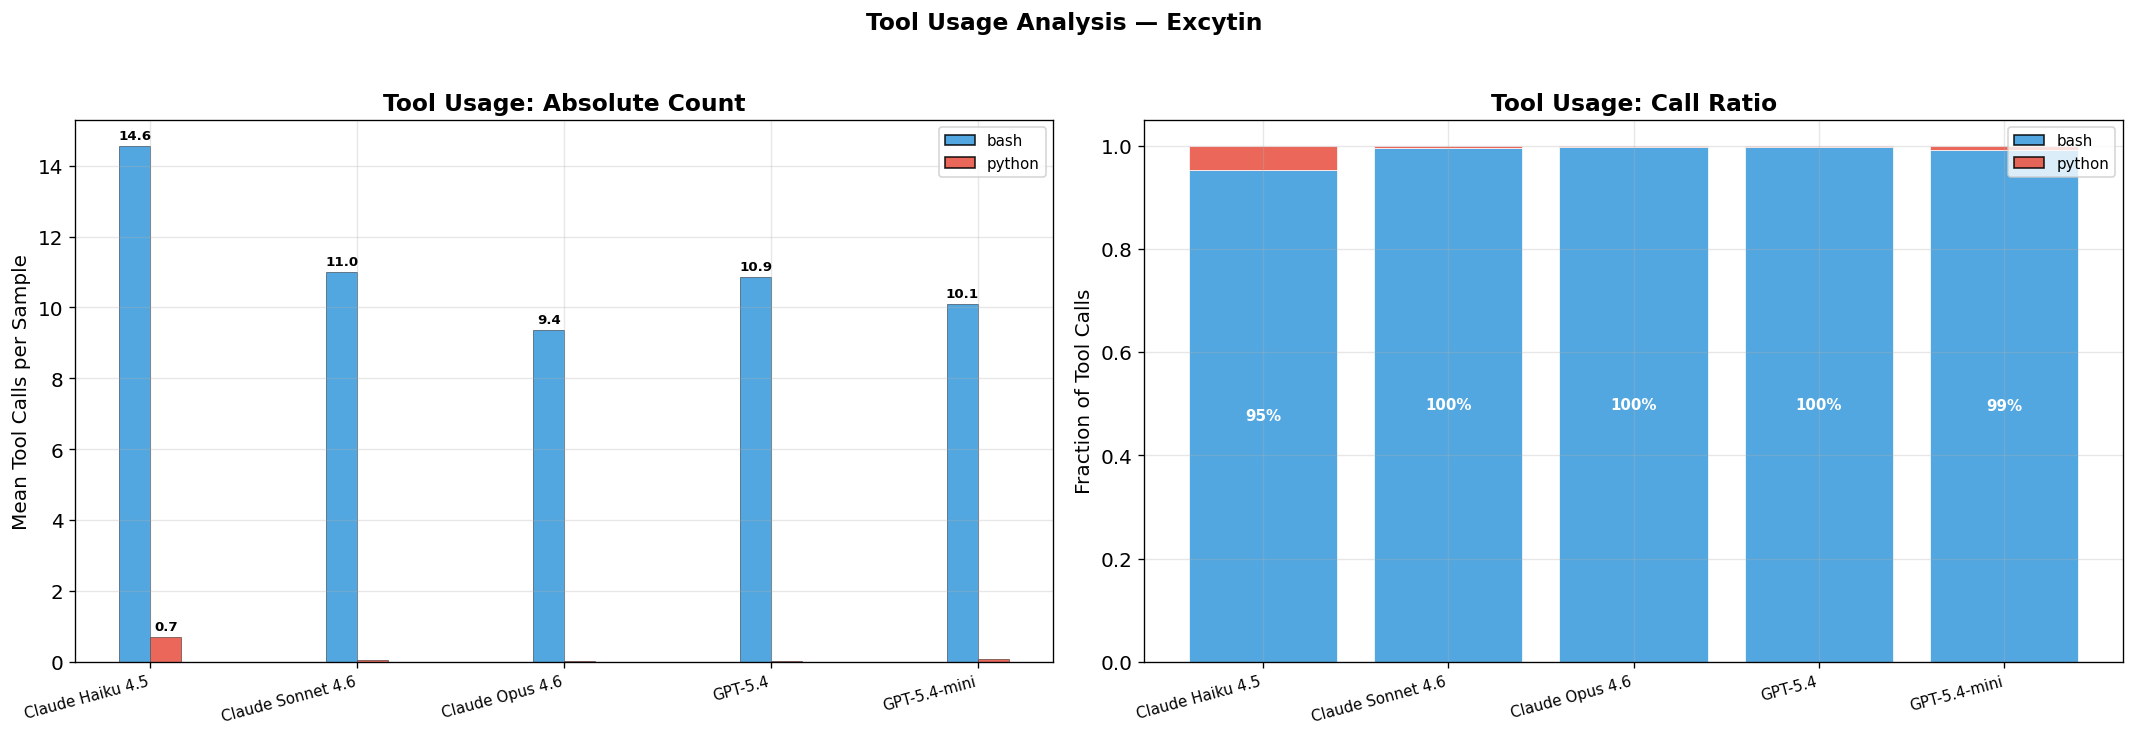

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9: Tool usage breakdown per model
# ══════════════════════════════════════════════════════════════════════════════
# Expand tool_counts dicts into individual columns
tool_expanded = traj_df['tool_counts'].apply(pd.Series).fillna(0)
for col in tool_expanded.columns:
    traj_df[f'tool_{col}'] = tool_expanded[col]

tool_cols = [c for c in traj_df.columns if c.startswith('tool_') and c != 'tool_counts']
tool_names = [c.replace('tool_', '') for c in tool_cols]

# ── Aggregate minor tools (<1% of calls across all configs) into "Other" ──
total_calls_all = traj_df['n_tool_calls'].sum()
tool_totals = {tname: traj_df[col].sum() for col, tname in zip(tool_cols, tool_names)}
major_tools = [t for t, v in tool_totals.items() if v / total_calls_all >= 0.01]
minor_tools = [t for t, v in tool_totals.items() if v / total_calls_all < 0.01]

if minor_tools:
    traj_df['tool_Other (<1%)'] = sum(traj_df[f'tool_{t}'] for t in minor_tools)
    minor_label = 'Other: ' + ', '.join(minor_tools)
    plot_tool_cols = [f'tool_{t}' for t in major_tools] + ['tool_Other (<1%)']
    plot_tool_names = major_tools + [minor_label]
else:
    plot_tool_cols = tool_cols
    plot_tool_names = tool_names

tool_palette = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Mean tool calls per tool
ax = axes[0]
bar_width = 0.15
x = np.arange(len(MODEL_ORDER))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    offset = (j - len(plot_tool_cols)/2 + 0.5) * bar_width
    means = [traj_df[traj_df['model'] == m][col].mean() for m in MODEL_ORDER]
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x + offset, means, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    for i, v in enumerate(means):
        if v > 0.3:
            ax.text(x[i] + offset, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
tool_handles = [mpatches.Patch(facecolor=tool_palette[j % len(tool_palette)], edgecolor='black',
                                alpha=0.85, label=tname) for j, tname in enumerate(plot_tool_names)]
ax.legend(handles=tool_handles, fontsize=9, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Tool Calls per Sample')
ax.set_title('Tool Usage: Absolute Count', fontweight='bold')

# Panel 2: Tool call ratios (stacked bar)
ax = axes[1]
bottoms = np.zeros(len(MODEL_ORDER))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    ratios = []
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        total = mdf['n_tool_calls'].sum()
        ratios.append(mdf[col].sum() / total if total > 0 else 0)
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x, ratios, color=color, edgecolor='white', linewidth=0.5, bottom=bottoms, alpha=0.85)
    for i, r in enumerate(ratios):
        if r > 0.05:
            ax.text(x[i], bottoms[i] + r/2, f'{r:.0%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottoms += ratios
ax.legend(handles=tool_handles, fontsize=9, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Fraction of Tool Calls')
ax.set_title('Tool Usage: Call Ratio', fontweight='bold')
ax.set_ylim(0, 1.05)

fig.suptitle(f'Tool Usage Analysis — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'tool_usage.png', bbox_inches='tight')
plt.show()

if minor_tools:
    print(f'\nTools aggregated into Other: {", ".join(minor_tools)}')

---

## 10. Time Efficiency & Reward Per Tool Call

### What this measures

Two dimensions of agent efficiency:

1. **Reward per tool call** — how much score does each model earn per unit of effort?
   $\text{Reward/Call} = \frac{\text{Mean SABER Score}}{\text{Mean Tool Calls}}$

2. **Reward per minute** — score per wall-clock minute of inference time

3. **Time per sample distribution** — how long does each model take to complete a task?

A model with high reward/call is "efficient" — it doesn't waste tool invocations. A model with low time but high reward is "fast and accurate."

### Key insights (Excytin)

- **Claude Opus 4.6** is the most efficient on both metrics: highest reward/call and reward/minute — highest score in fewest tool calls and fastest time
- **Claude Haiku 4.5** has the lowest reward/call — it makes many tool calls for modest gains
- **GPT-5.4** has the lowest reward/minute despite having the highest score — because it takes much longer per sample (6–9× slower than Claude models)
- Time distributions reveal GPT-5.4 as a major outlier with 60+ minute tails, while all Claude models complete in under 5 minutes

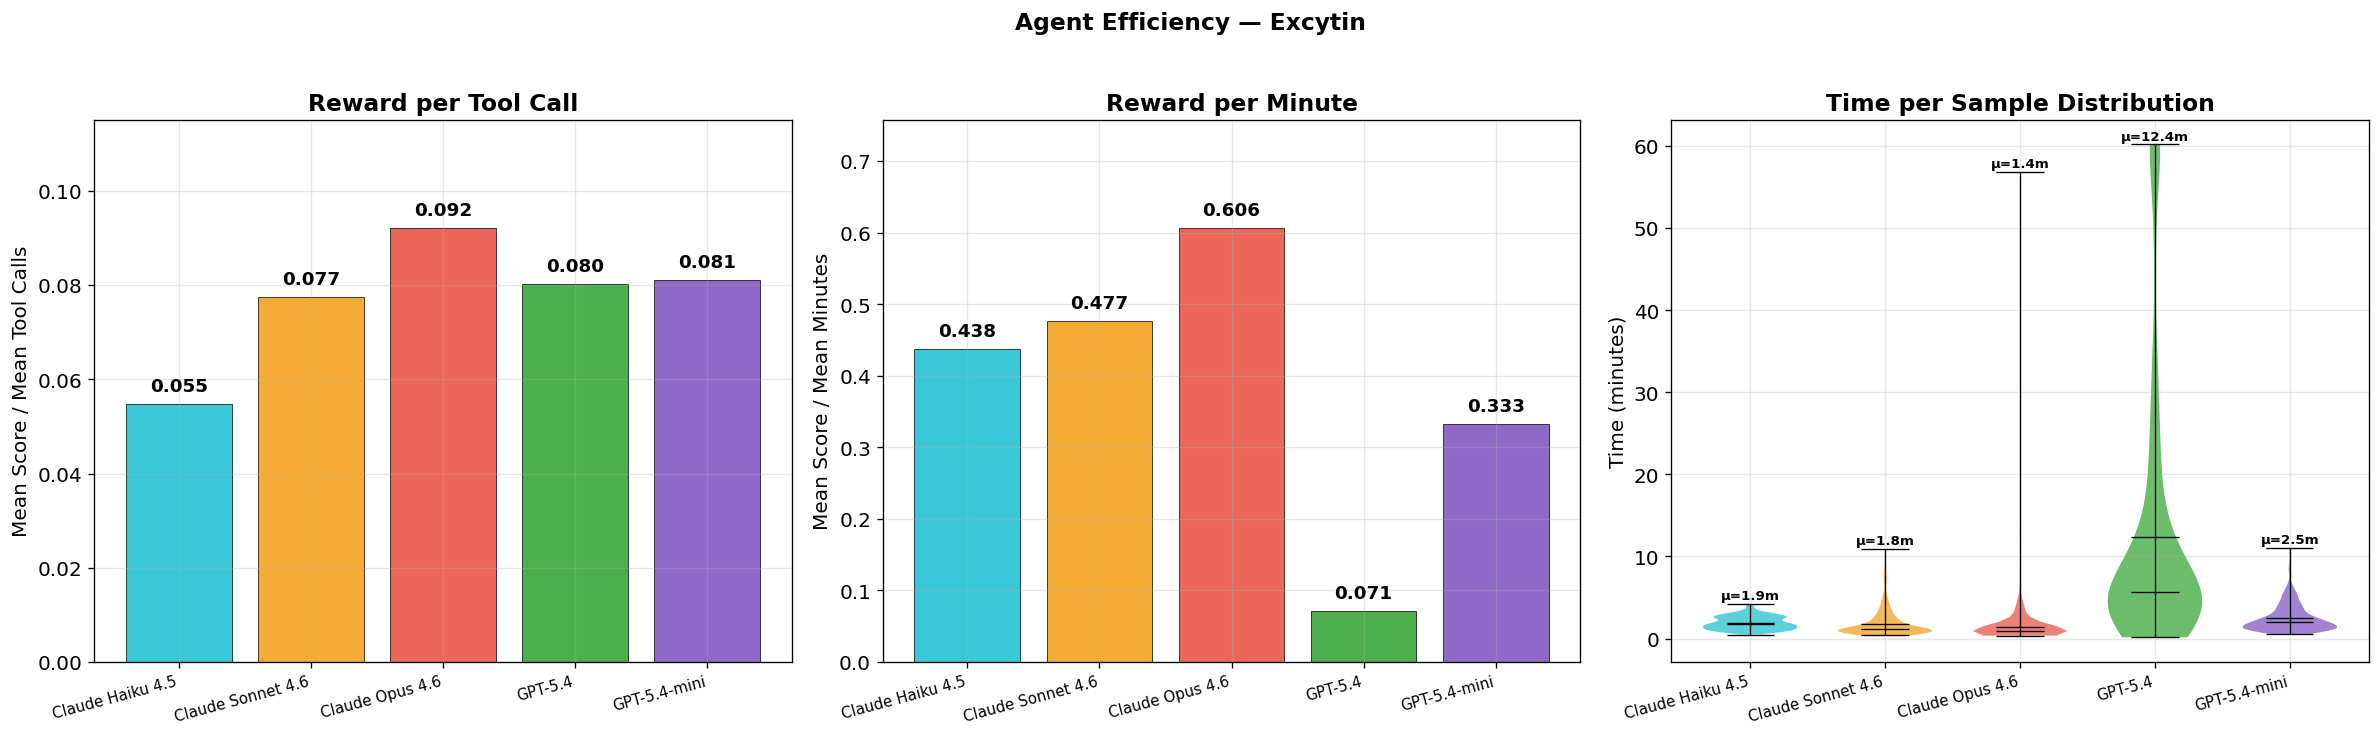

═══ Efficiency Summary ═══
Model                      Score   Calls    Time   Rew/Call    Rew/Min
──────────────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838    15.3    1.9m     0.0548     0.4378
Claude Sonnet 4.6          0.857    11.1    1.8m     0.0774     0.4769
Claude Opus 4.6            0.865     9.4    1.4m     0.0921     0.6062
GPT-5.4                    0.875    10.9   12.4m     0.0803     0.0707
GPT-5.4-mini               0.827    10.2    2.5m     0.0811     0.3331


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 10: Time efficiency and reward per tool call
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Reward per tool call
ax = axes[0]
reward_per_call = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    rpc = mdf['score'].mean() / mdf['n_tool_calls'].mean()
    reward_per_call.append(rpc)
for i, (m, rpc) in enumerate(zip(MODEL_ORDER, reward_per_call)):
    ax.bar(i, rpc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpc + max(reward_per_call)*0.02, f'{rpc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Score / Mean Tool Calls')
ax.set_title('Reward per Tool Call', fontweight='bold')
ax.set_ylim(0, max(reward_per_call) * 1.25)

# Panel 2: Reward per minute
ax = axes[1]
reward_per_min = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    rpm = mdf['score'].mean() / (mdf['total_time'].mean() / 60)
    reward_per_min.append(rpm)
for i, (m, rpm) in enumerate(zip(MODEL_ORDER, reward_per_min)):
    ax.bar(i, rpm, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpm + max(reward_per_min)*0.02, f'{rpm:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Score / Mean Minutes')
ax.set_title('Reward per Minute', fontweight='bold')
ax.set_ylim(0, max(reward_per_min) * 1.25)

# Panel 3: Time per sample distributions
ax = axes[2]
for i, m in enumerate(MODEL_ORDER):
    data = traj_df[traj_df['model'] == m]['total_time'].values / 60  # Convert to minutes
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, data.max() + 0.2, f'μ={np.mean(data):.1f}m', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Time (minutes)')
ax.set_title('Time per Sample Distribution', fontweight='bold')

fig.suptitle(f'Agent Efficiency — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'agent_efficiency.png', bbox_inches='tight')
plt.show()

# Summary table
print('═══ Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Calls":>7s} {"Time":>7s} {"Rew/Call":>10s} {"Rew/Min":>10s}')
print('─' * 70)
for m, rpc, rpm in zip(MODEL_ORDER, reward_per_call, reward_per_min):
    mdf = traj_df[traj_df['model'] == m]
    print(f'{m:25s} {mdf["score"].mean():6.3f} {mdf["n_tool_calls"].mean():7.1f} '
          f'{mdf["total_time"].mean()/60:6.1f}m {rpc:10.4f} {rpm:10.4f}')

---

## 11. Score Outcome Segmentation by Effort

### What this measures

Segments samples into **effort quartiles** by tool-call count and shows what fraction of tasks in each quartile achieve a **perfect score** (1.0) vs. **zero** (0.0) vs. **partial** (0 < score < 1).

This reveals whether:
- High-effort tasks are the ones the model struggles with (many tool calls → partial/zero)
- Quick tasks are easy wins (few tool calls → perfect score)
- More tool calls actually convert to better outcomes

### Key insights (Excytin)

- **Claude Opus 4.6** degrades least: ~85% perfect in Q1 → ~68% in Q4 (only -17pp), while Haiku drops from ~77% → ~62% (-15pp)
- The perfect-score rate drops from ~77–85% in Q1 to ~62–72% in Q4 for most models
- Across all models, **Q4 (highest effort) consistently has the most zeros and fewest perfects** — confirming that difficult tasks drive more tool calls
- Zero-score rate roughly doubles from Q1 to Q4 across all models, showing high effort is a signal of failure

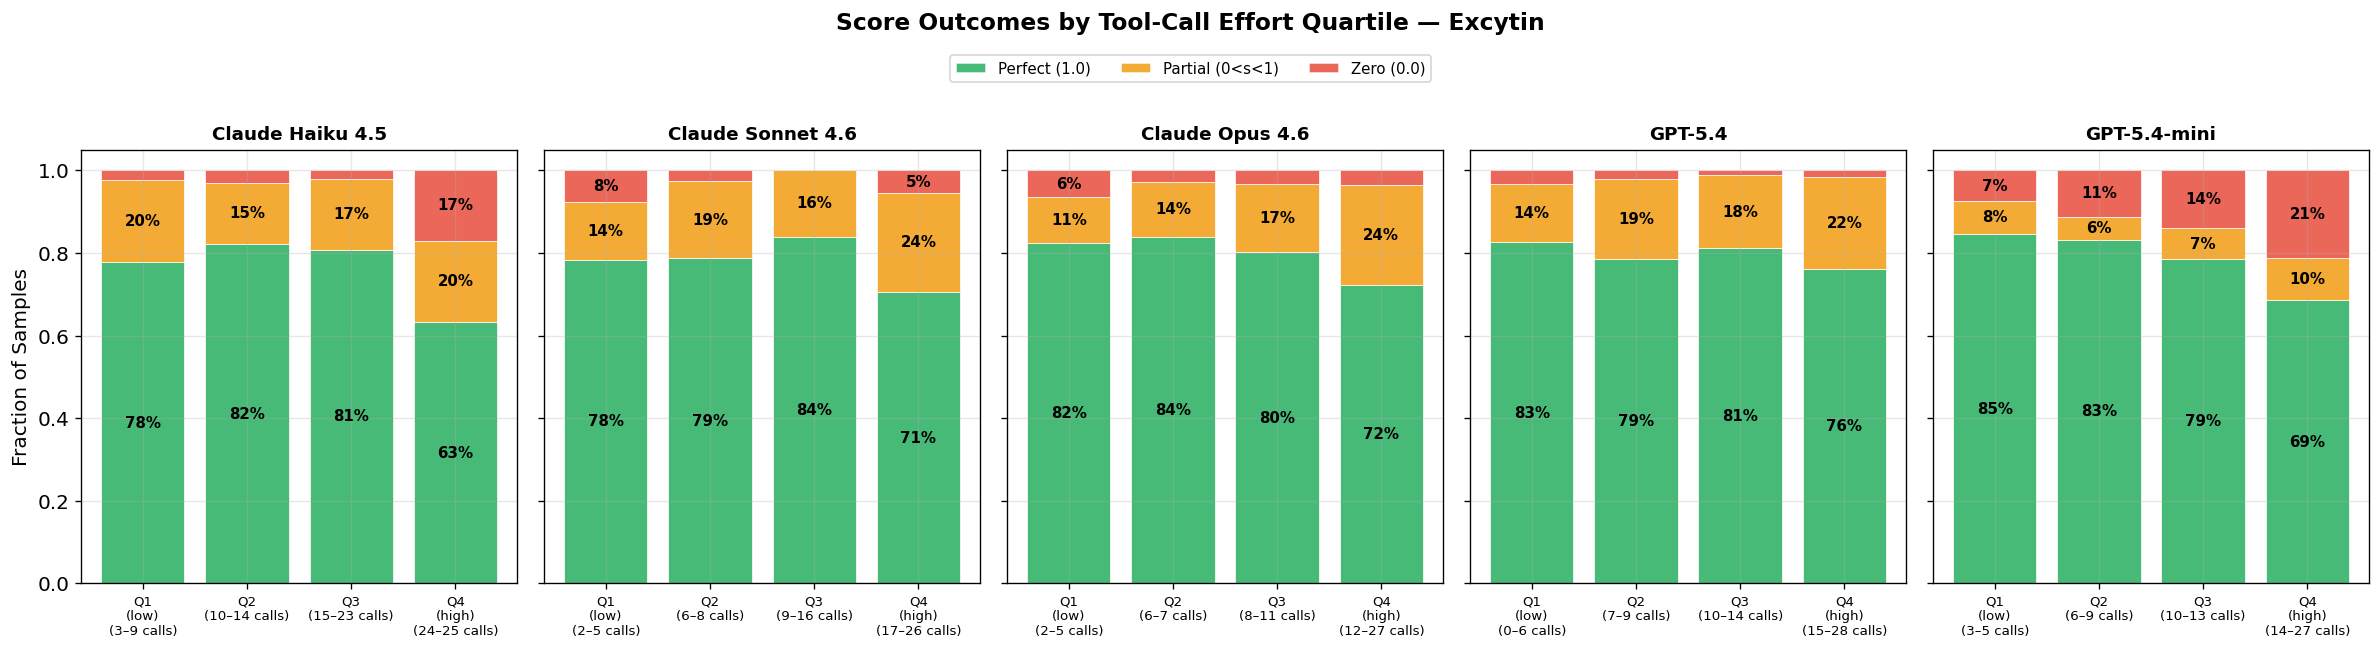

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 11: Score outcome segmentation by tool-call effort quartile
# ══════════════════════════════════════════════════════════════════════════════
outcome_colors = {'Perfect (1.0)': '#27AE60', 'Partial (0<s<1)': '#F39C12', 'Zero (0.0)': '#E74C3C'}
n_models = len(MODEL_ORDER)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, m in zip(axes, MODEL_ORDER):
    mdf = traj_df[traj_df['model'] == m].copy()
    mdf['effort_q'] = pd.qcut(mdf['n_tool_calls'], q=4, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'], duplicates='drop')

    # Classify outcomes
    mdf['outcome'] = 'Partial (0<s<1)'
    mdf.loc[mdf['score'] >= 1.0 - 1e-6, 'outcome'] = 'Perfect (1.0)'
    mdf.loc[mdf['score'] <= 1e-6, 'outcome'] = 'Zero (0.0)'

    ct = pd.crosstab(mdf['effort_q'], mdf['outcome'], normalize='index')
    ct = ct.reindex(columns=['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)'], fill_value=0)

    bottoms = np.zeros(len(ct))
    for outcome_cat in ['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)']:
        if outcome_cat not in ct.columns:
            continue
        vals = ct[outcome_cat].values
        ax.bar(range(len(ct)), vals, bottom=bottoms, color=outcome_colors[outcome_cat],
               edgecolor='white', linewidth=0.5, alpha=0.85)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.05:
                ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center', fontsize=9, fontweight='bold')
        bottoms += vals

    # Tool call range labels
    call_ranges = mdf.groupby('effort_q')['n_tool_calls'].agg(['min', 'max'])
    xlabels = [f'{r.Index}\n({int(r.min)}–{int(r.max)} calls)' for r in call_ranges.itertuples()]
    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_title(m, fontweight='bold', fontsize=11)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel('Fraction of Samples')
handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=k) for k, c in outcome_colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f'Score Outcomes by Tool-Call Effort Quartile — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.08)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'effort_outcome_segmentation.png', bbox_inches='tight')
plt.show()

---

## 12. Cross-Model Difficulty Agreement

### What this measures

Do models agree on which tasks are hard? For each pair of models, computes the **Spearman rank correlation** of their per-sample scores.

- **High correlation (> 0.7)** = models agree on task difficulty — some tasks are inherently harder
- **Low correlation (< 0.3)** = models struggle on different tasks — strengths are complementary
- Useful for **ensemble strategies**: low correlation = models complement each other

- The moderate correlations suggest potential for **ensemble strategies** combining Claude and GPT models

### Key insights (Excytin)- All correlations are statistically significant (p < 0.05) — task difficulty is a real signal, not noise

- **GPT-5.4 ↔ GPT-5.4-mini** have the *lowest* correlation (ρ = 0.41) — surprisingly, the same family disagrees most

- **Moderate agreement overall** (ρ = 0.41–0.64) — models partially agree on which tasks are hard but have distinct strengths- **Claude Sonnet ↔ Opus** have the highest correlation (ρ = 0.64) — same model family, similar failure modes

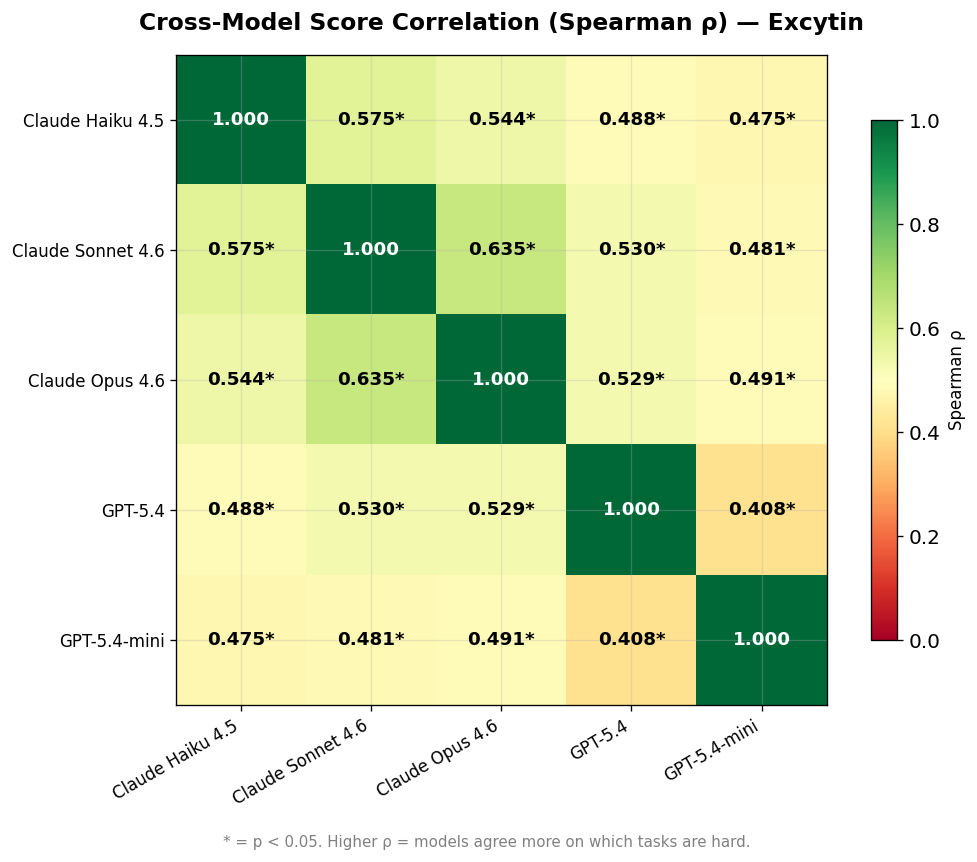

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 12: Cross-model difficulty agreement (Spearman correlation heatmap)
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

# Pivot: rows=sample_id, columns=model, values=score
score_pivot = samples_df.pivot(index='sample_id', columns='model', values='score').reindex(columns=MODEL_ORDER)

# Compute pairwise Spearman rank correlation
n = len(MODEL_ORDER)
corr_matrix = np.ones((n, n))
p_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        m1, m2 = MODEL_ORDER[i], MODEL_ORDER[j]
        valid = score_pivot[[m1, m2]].dropna()
        if len(valid) > 2:
            rho, p = spearmanr(valid[m1], valid[m2])
            corr_matrix[i, j] = corr_matrix[j, i] = rho
            p_matrix[i, j] = p_matrix[j, i] = p

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')

# Annotate cells
for i in range(n):
    for j in range(n):
        val = corr_matrix[i, j]
        text_color = 'white' if val < 0.4 or val > 0.85 else 'black'
        sig = '' if i == j else ('*' if p_matrix[i, j] < 0.05 else '')
        ax.text(j, i, f'{val:.3f}{sig}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)

ax.set_xticks(range(n)); ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_title(f'Cross-Model Score Correlation (Spearman ρ) — {DOMAIN_NAME}', fontweight='bold', pad=15)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Spearman ρ', fontsize=10)
fig.text(0.5, -0.02, '* = p < 0.05. Higher ρ = models agree more on which tasks are hard.',
         ha='center', fontsize=9, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cross_model_correlation.png', bbox_inches='tight')
plt.show()

---

## Next Steps

### Domain-specific experiments

Experiment 2 (Per-Group Breakdown) in this notebook is domain-specific — it requires a `GROUP_FN` tailored to each domain. For additional domain-specific analysis beyond per-group breakdown:
- **Excytin:** [`excytin_analysis.ipynb`](excytin_analysis.ipynb) — per-incident submission vs. checkpoint gap heatmap + SQL query outcome analysis (error/empty/success/large-result classification)
- **CyBench:** [`cybench_analysis.ipynb`](cybench_analysis.ipynb) — per-challenge submission vs. checkpoint gap heatmap

### Adding your own models

1. Run: `uv run inspect eval domains/<domain> --model <model_id>`
2. Copy the `.eval` file to `latest_experiments/<domain>/`
3. Edit the **Configuration cell** above
4. Re-run the notebook

### Switching domains

To analyze a different domain, change three things in the Configuration cell:
1. `DOMAIN_NAME`, `LOG_DIR` — point to the domain's logs
2. `EVAL_LOGS` / `COLORS` / `PRICING` — your models for that domain
3. `GROUP_FN` / `GROUP_LABEL` — build a grouping function for the domain's task structure

### Data loading notes

All log parsing uses **inspect_ai's typed log API**:
- `read_eval_log(header_only=True)` for run-level results and stats
- `read_eval_log_sample_summaries()` for per-sample scores, timing, and model usage
- `read_eval_log_sample(id=...)` for full message/tool-call detail per sample

This avoids raw ZIP/JSON parsing and provides typed access to all eval data.

### Further reading

- **[README.md](../README.md)** — Installation, domains, agents, CLI
- `uv run inspect view` — Interactive log viewer